In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path


In [2]:
carpeta_datos = Path(r"D:\ProyectoAnalisisElectrico\PotencialesClientes")
df = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual_actives_resultados.parquet")
df_dt = pd.read_parquet(carpeta_datos / "2505_2604_clustered_porcentual_actives_processed.parquet")


In [61]:
df_dt.columns

Index(['clave', 'RUT_CLIENTE', 'REGION_CLIENTE', 'macrozona', 'Zona', 'Hora',
       'medida_count', 'medida_min', 'CLIENTE', 'CLIENTE_log', 'n_clientes',
       'TIPO', 'NOMBRE_ESTABLECIMIENTO', 'SECTOR', 'SUBSECTOR', 'RUBRO',
       'DEMANDA_CALOR_MWH_sum', 'DEMANDA_CALOR_MWH_mean',
       'DEMANDA_CALOR_MWH_std', 'DEMANDA_CALOR_MWH_max',
       'DEMANDA_CALOR_MWH_min', 'RUT_PROVEEDOR', 'RUT_PROVEEDOR_log',
       'n_rut_proveedores', 'PROVEEDOR', 'PROVEEDOR_log', 'n_proveedores',
       'nombre_barra', 'nombre_barra_log', 'n_nombres_barra', 'tension',
       'tension_log', 'n_tensiones', 'Nombre_Corto', 'Nombre_Corto_log',
       'n_nombres_cortos', 'periodo_last', 'periodos_log', 'meses_operados',
       'medida_mean', 'medida_std', 'CMg[CLP/KWh]_mean', 'CMg[CLP/KWh]_std',
       'CMg[CLP/KWh]_count', 'valorizado_CLP_mean', 'valorizado_CLP_std',
       'valorizado_CLP_count', 'medida_total', 'medida_porcentual',
       'clave_unica', 'id_cluster', 'metodo_cluster', 'dtw_window',
  

In [4]:
df.columns

Index(['macrozona', 'id_cluster', 'clientes_del_cluster', 'lista_ruts',
       'lista_nombres', 'clientes_totales_macrozona', 'sect_rut_cluster',
       'total_rut_cluster', 'sect_claves_cluster', 'total_claves_cluster',
       'sect_energia_cluster', 'total_energia_cluster_mwh',
       'sect_calor_cluster', 'total_calor_cluster_mwh', 'sect_rut_macrozona',
       'total_rut_macrozona', 'sect_claves_macrozona',
       'total_claves_macrozona', 'sect_energia_macrozona',
       'total_energia_macrozona_mwh', 'sect_calor_macrozona',
       'total_calor_macrozona_mwh', 'factor_forma_promedio',
       'factor_forma_std', 'capacidad_carga_promedio', 'capacidad_carga_std',
       'potencia_max_promedio_kw'],
      dtype='str')

In [ ]:
# ==========================================
# 1. CONFIGURACIÓN GLOBAL (COLORES)
# ==========================================
COLORES_SECTORES = {
    'Alimentos': '#2980B9',         
    'Cemento': '#7F8C8D',           
    'Comercial, Público, Residencial (CPR)': '#16A085', 
    'Energético': '#C0392B',        
    'Industrial': '#2C3E50',        
    'Industrias Varias': '#8E44AD', 
    'Minero': '#B87333',            
    'Papel y Celulosa': '#27AE60',  
    'Petroquímica': '#D35400'       
}

# ==========================================
# 2. DEFINICIÓN DE LA FUNCIÓN ACTUALIZADA
# ==========================================
def graficar_composicion_sectorial(df, 
                                   col_proporciones, 
                                   col_totales, 
                                   sufijo_total="RUTs", 
                                   titulo="Composición Sectorial por Clúster y Macrozona", 
                                   xlabel="Proporción de Clientes",
                                   formato_cientifico=False): # NUEVO PARÁMETRO
    
    # --- PREPARACIÓN DE DATOS ---
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    
    df_plot = df[['macrozona', 'id_cluster', col_proporciones, col_totales]].copy()
    df_plot['macrozona'] = pd.Categorical(df_plot['macrozona'], categories=orden_macrozonas, ordered=True)

    def parse_sectores(texto):
        if pd.isna(texto) or texto == '':
            return {}
        sectores_dict = {}
        for par in texto.split('::'):
            if '_' in par:
                sector, valor = par.rsplit('_', 1) 
                sectores_dict[sector.strip()] = float(valor)
        return sectores_dict

    columnas_sectores = df_plot[col_proporciones].apply(parse_sectores).apply(pd.Series).fillna(0)
    df_plot = pd.concat([df_plot, columnas_sectores], axis=1)
    df_plot = df_plot.sort_values(['macrozona', 'id_cluster']).reset_index(drop=True)

    # --- GENERACIÓN DEL GRÁFICO ---
    cmap_fallback = plt.get_cmap('Set2') 
    nombres_sectores = columnas_sectores.columns

    fig, ax = plt.subplots(figsize=(14, max(7, len(df_plot) * 0.45)))

    y_labels = df_plot['macrozona'].astype(str) + " - C" + df_plot['id_cluster'].astype(str)
    y_pos = np.arange(len(df_plot))
    posicion_izquierda = np.zeros(len(df_plot))

    # Dibujar barras
    for i, sector in enumerate(nombres_sectores):
        valores_sector = df_plot[sector]
        color_barra = COLORES_SECTORES.get(sector.strip(), cmap_fallback(i % 8))
        
        ax.barh(y_pos, valores_sector, left=posicion_izquierda, label=sector, 
                color=color_barra, edgecolor='white', linewidth=0.8)
        posicion_izquierda += valores_sector

    # --- APLICACIÓN DE LA NOTACIÓN CIENTÍFICA ---
    for i, total in enumerate(df_plot[col_totales]):
        # Si el parámetro es True, aplicamos el formato científico (ej: 1.13E+07)
        if formato_cientifico:
            texto_valor = f"{total:.2E} {sufijo_total}"
        # Si es False, lo mantenemos como entero normal
        else:
            texto_valor = f"{int(total)} {sufijo_total}"
            
        ax.text(1.02, y_pos[i], texto_valor, va='center', ha='left', 
                fontsize=10, color='#333333', fontweight='500')

    # --- ESTILOS Y FORMATO FINAL ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
    ax.invert_yaxis()  

    ax.set_ylim(len(df_plot) - 0.5, -0.5)
    
    # Aumentamos un poco el límite X para asegurar que la notación científica quepa bien
    ax.set_xlim(0, 1.18) 

    ax.set_xlabel(xlabel, color='#555555', fontsize=11, labelpad=10)
    ax.set_title(titulo, color='#222222', fontsize=14, fontweight='bold', pad=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.tick_params(axis='both', colors='#555555', length=4)

    ax.xaxis.grid(True, linestyle='--', color='#eeeeee', linewidth=1)
    ax.set_axisbelow(True) 

    ax.legend(title='Sectores', bbox_to_anchor=(1.05, 1), loc='upper left', 
              frameon=False, title_fontproperties={'weight': 'bold'})

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}' if x <= 1.0 else ''))

    plt.tight_layout()
    plt.show()

In [5]:
# 4. CÓMO USAR LA FUNCIÓN
# ==========================================
# Definimos los clústeres target mediante un diccionario
clusters_target = {
    'Norte Grande': [1, 2],
    'Centro': [1, 2, 3],
    'Centro Sur': [1, 2, 4, 5],
    'Sur': [1, 2]
}

findfont: Failed to find font weight 500, now using 400.


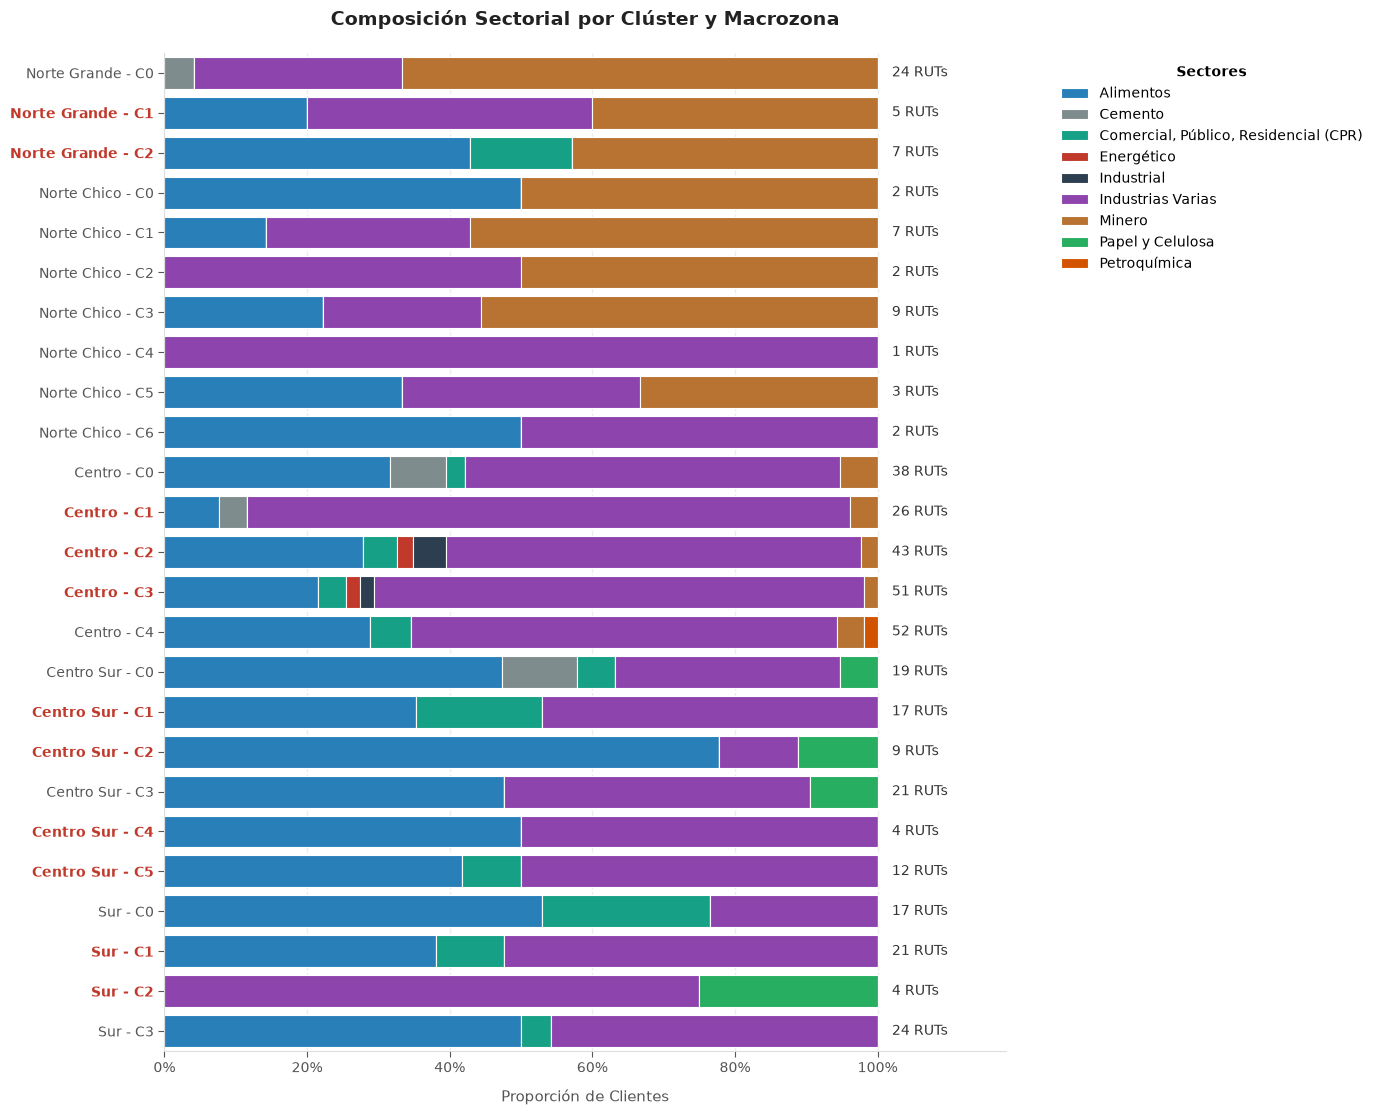

In [ ]:


# Llamamos a la función pasándole el diccionario (ejemplo con RUTs)
graficar_composicion_sectorial(
     df=df,
     col_proporciones='sect_rut_cluster',
     col_totales='total_rut_cluster',
     sufijo_total='RUTs',
     titulo='Composición Sectorial por Clúster y Macrozona (RUTs)',

     clusters_interes=clusters_target
)

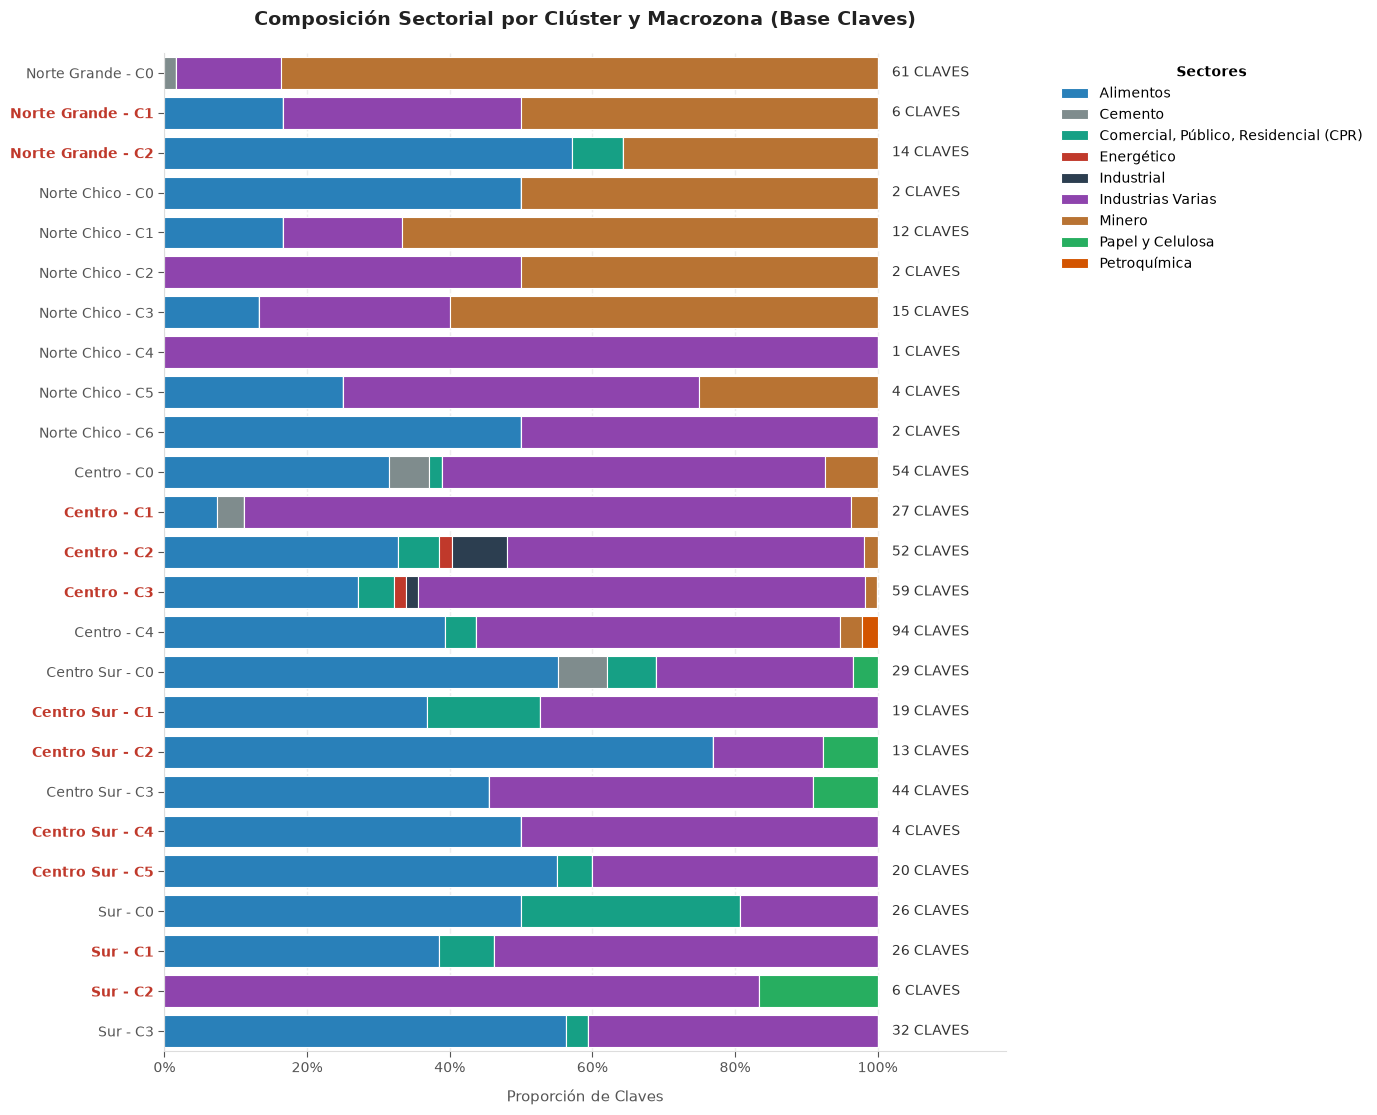

In [ ]:
# Gráfico para CLAVES
graficar_composicion_sectorial(
    df=df,
    col_proporciones='sect_claves_cluster',
    col_totales='total_claves_cluster',
    sufijo_total='CLAVES',
    titulo='Composición Sectorial por Clúster y Macrozona (Claves)',
    xlabel='Proporción de Claves',
    clusters_interes=clusters_target

)

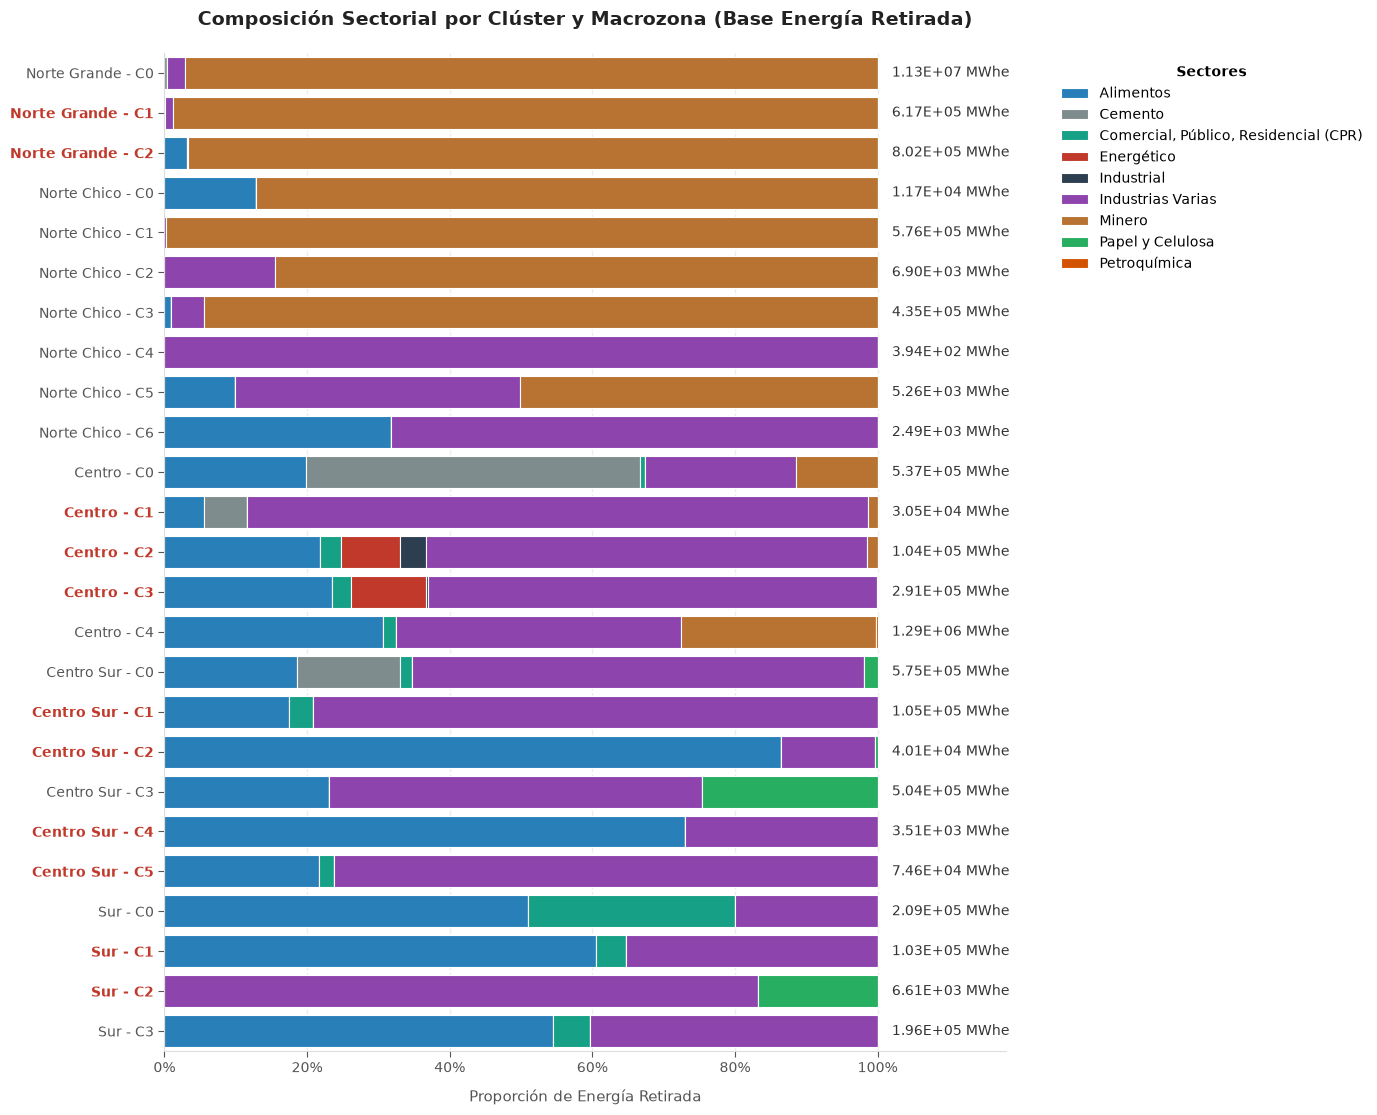

In [ ]:
df["total_energia_cluster_mwh"] = abs(df["total_energia_cluster_mwh"])

graficar_composicion_sectorial(
    df=df,
    col_proporciones='sect_energia_cluster',
    col_totales='total_energia_cluster_mwh',
    sufijo_total='MWhe',
    titulo='Composición Sectorial por Clúster y Macrozona (Energía Retirada)',
    xlabel='Proporción de Energía Retirada',
    formato_cientifico=True, 
    clusters_interes=clusters_target

)

In [9]:
df.columns

Index(['macrozona', 'id_cluster', 'clientes_del_cluster', 'lista_ruts',
       'lista_nombres', 'clientes_totales_macrozona', 'sect_rut_cluster',
       'total_rut_cluster', 'sect_claves_cluster', 'total_claves_cluster',
       'sect_energia_cluster', 'total_energia_cluster_mwh',
       'sect_calor_cluster', 'total_calor_cluster_mwh', 'sect_rut_macrozona',
       'total_rut_macrozona', 'sect_claves_macrozona',
       'total_claves_macrozona', 'sect_energia_macrozona',
       'total_energia_macrozona_mwh', 'sect_calor_macrozona',
       'total_calor_macrozona_mwh', 'factor_forma_promedio',
       'factor_forma_std', 'capacidad_carga_promedio', 'capacidad_carga_std',
       'potencia_max_promedio_kw'],
      dtype='str')

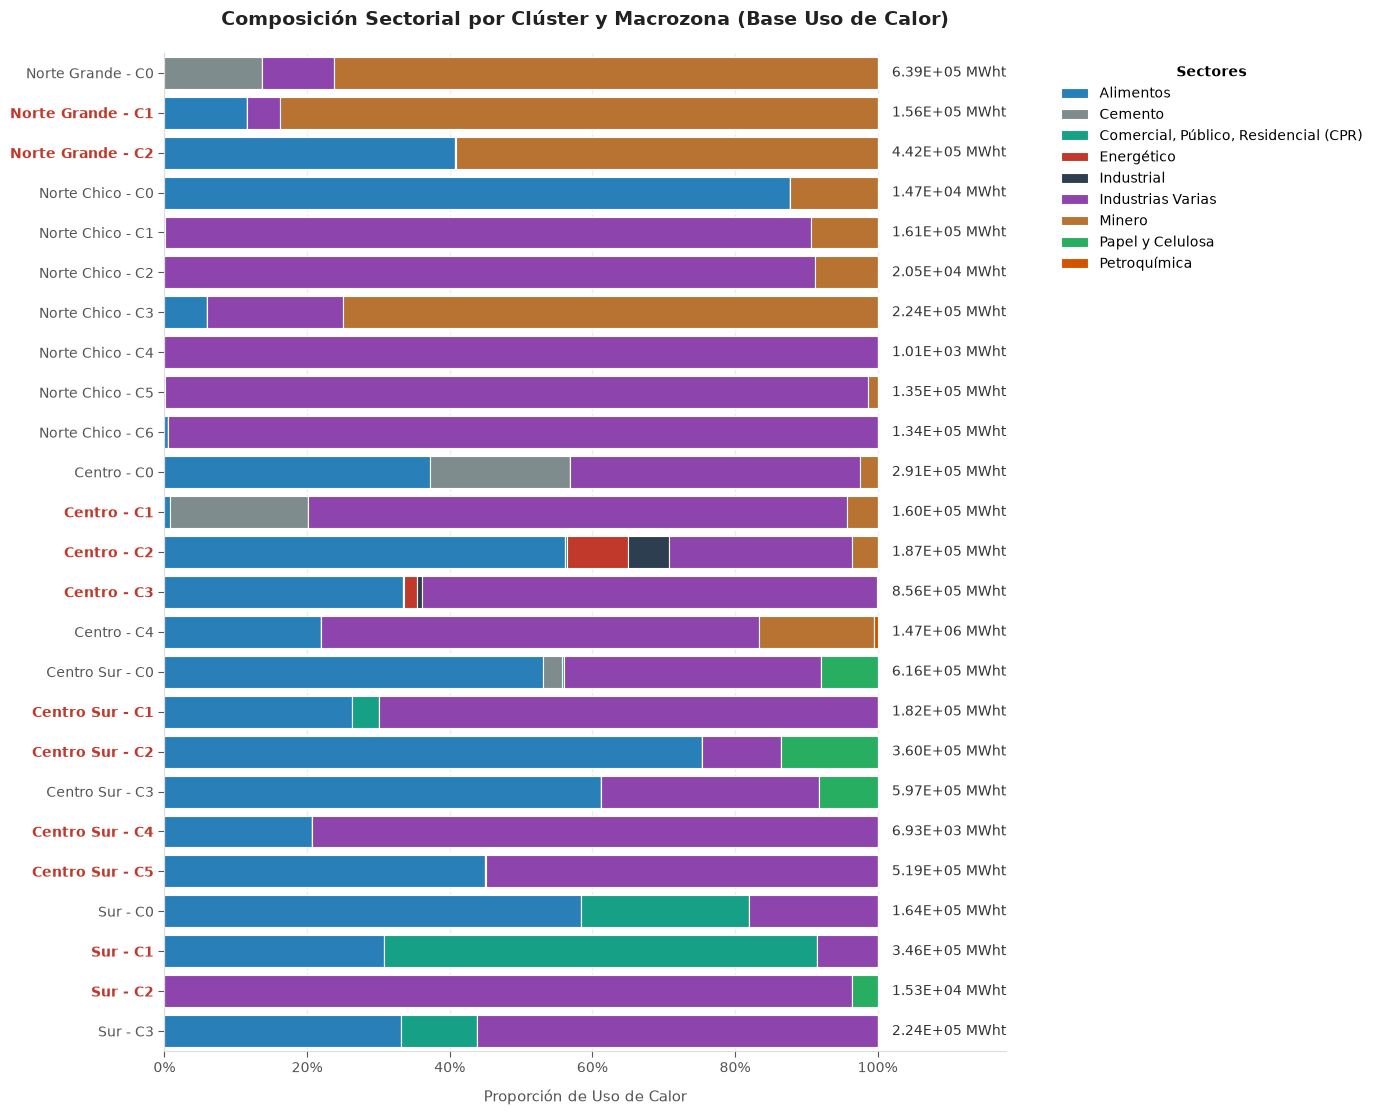

In [ ]:
graficar_composicion_sectorial(
    df=df,
    col_proporciones='sect_calor_cluster',
    col_totales='total_calor_cluster_mwh',
    sufijo_total='MWht',
    titulo='Composición Sectorial por Clúster y Macrozona (Uso de Calor)',
    xlabel='Proporción de Uso de Calor',
    formato_cientifico=True, 
    clusters_interes=clusters_target

)

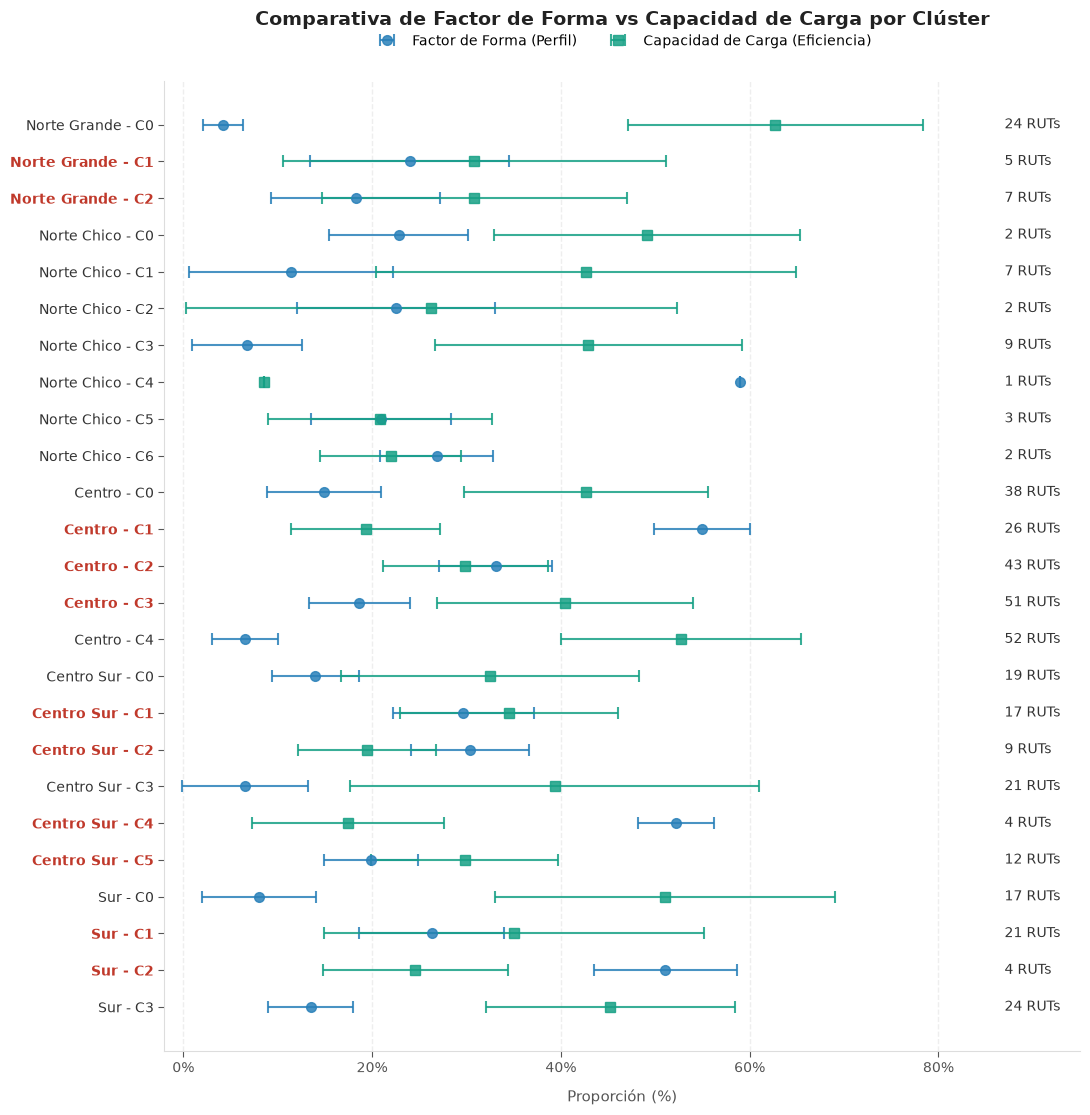

In [ ]:
# ==========================================
# DEFINICIÓN DE CLÚSTERES DE INTERÉS (TARGET)
# ==========================================
clusters_target = {
    'Norte Grande': [1, 2],
    'Centro': [1, 2, 3],
    'Centro Sur': [1, 2, 4, 5],
    'Sur': [1, 2]
}

# ==========================================
# PREPARACIÓN DE DATOS
# ==========================================
orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']

columnas_metricas = [
    'macrozona', 'id_cluster', 
    'factor_forma_promedio', 'factor_forma_std', 
    'capacidad_carga_promedio', 'capacidad_carga_std',
    'total_rut_cluster'  
]
df_plot = df[columnas_metricas].copy()

df_plot['macrozona'] = pd.Categorical(df_plot['macrozona'], categories=orden_macrozonas, ordered=True)
df_plot = df_plot.sort_values(['macrozona', 'id_cluster']).reset_index(drop=True)

y_labels = df_plot['macrozona'].astype(str) + " - C" + df_plot['id_cluster'].astype(str)
y_pos = np.arange(len(df_plot))

# ==========================================
# GENERACIÓN DEL GRÁFICO
# ==========================================

fig, ax = plt.subplots(figsize=(11, max(7, len(df_plot) * 0.45)))

# --- MÉTRICA 1: FACTOR DE FORMA ---
ax.errorbar(
    x=df_plot['factor_forma_promedio'], y=y_pos, xerr=df_plot['factor_forma_std'],
    fmt='o',                    
    color='#2980B9',            
    ecolor='#2980B9',           
    alpha=0.85,                 
    elinewidth=1.5,             
    capsize=4, capthick=1.5,    
    markersize=7,               
    label='Factor de Forma (Perfil)'
)

# --- MÉTRICA 2: CAPACIDAD DE CARGA ---
ax.errorbar(
    x=df_plot['capacidad_carga_promedio'], y=y_pos, xerr=df_plot['capacidad_carga_std'],
    fmt='s',                    
    color='#16A085',            
    ecolor='#16A085',           
    alpha=0.85,                 
    elinewidth=1.5,             
    capsize=4, capthick=1.5,    
    markersize=7,               
    label='Capacidad de Carga (Eficiencia)'
)

# --- TEXTO DE RUTs ---
for i, total in enumerate(df_plot['total_rut_cluster']):
    ax.text(0.87, y_pos[i], f"{int(total)} RUTs", va='center', ha='left', 
            fontsize=10, color='#333333', fontweight='500')

# ==========================================
# ESTILOS Y FORMATO
# ==========================================

ax.set_title('Comparativa de Factor de Forma vs Capacidad de Carga por Clúster', 
             color='#222222', fontsize=14, fontweight='bold', pad=40)
ax.set_xlabel('Proporción (%)', color='#555555', fontsize=11, labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

ax.xaxis.grid(True, linestyle='--', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True) 

ax.set_xlim(-0.02, 0.95)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='both', colors='#555555', length=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
ax.invert_yaxis()

# ==========================================
# LÓGICA PARA RESALTAR CLÚSTERES DE INTERÉS
# ==========================================
etiquetas_y = ax.get_yticklabels()

for index, row in df_plot.iterrows():
    macrozona_actual = row['macrozona']
    cluster_actual = row['id_cluster']
    
    # Verificamos si existe en nuestro diccionario
    if macrozona_actual in clusters_target and cluster_actual in clusters_target[macrozona_actual]:
        etiquetas_y[index].set_color('#C0392B')       # Rojo intenso corporativo
        etiquetas_y[index].set_fontweight('bold')     # Negrita

# ==========================================
# LEYENDA Y RENDERIZADO
# ==========================================
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

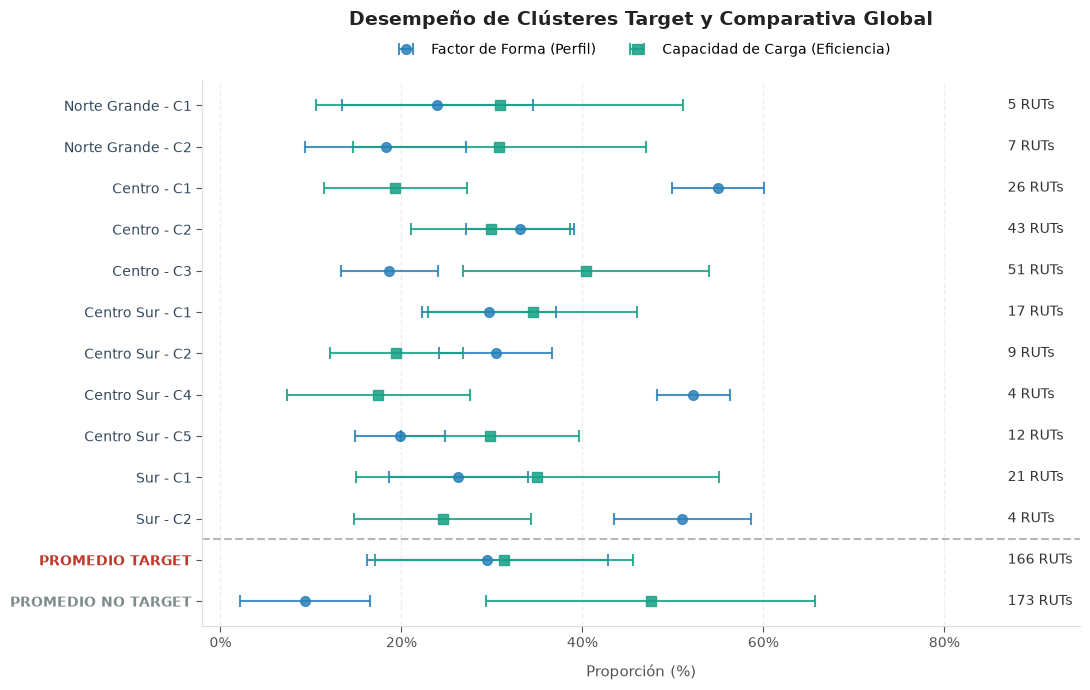

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. DEFINICIÓN DE CLÚSTERES DE INTERÉS (TARGET)
# ==========================================
clusters_target = {
    'Norte Grande': [1, 2],
    'Centro': [1, 2, 3],
    'Centro Sur': [1, 2, 4, 5],
    'Sur': [1, 2]
}

# Función auxiliar para identificar si una fila es Target
def es_target(row):
    mz = row['macrozona']
    cl = row['id_cluster']
    return mz in clusters_target and cl in clusters_target.get(mz, [])

# ==========================================
# 2. FILTRAR DATOS ORIGINALES (SOLO TARGETS)
# ==========================================
# Marcamos y filtramos en df
df['is_target'] = df.apply(es_target, axis=1)
df_plot = df[df['is_target']].copy()

orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
df_plot['macrozona'] = pd.Categorical(df_plot['macrozona'], categories=orden_macrozonas, ordered=True)
df_plot = df_plot.sort_values(['macrozona', 'id_cluster']).reset_index(drop=True)

# ==========================================
# 3. CALCULAR PROMEDIOS GLOBALES USANDO df_dt
# ==========================================
# Marcamos los targets en la base a nivel de clave_unica (df_dt)
df_dt['is_target'] = df_dt.apply(es_target, axis=1)

# IMPORTANTE: Reemplaza 'rut' por el nombre exacto de la columna de RUT en tu df_dt
resumen_dt = df_dt.groupby('is_target').agg(
    factor_forma_promedio=('factor_forma', 'mean'),
    factor_forma_std=('factor_forma', 'std'),
    capacidad_carga_promedio=('capacidad_carga', 'mean'),
    capacidad_carga_std=('capacidad_carga', 'std'),
    total_rut_cluster=('RUT_CLIENTE', 'nunique')  # Cuenta RUTs únicos, no claves
).reset_index()

target_stats = resumen_dt[resumen_dt['is_target'] == True].iloc[0]
nontarget_stats = resumen_dt[resumen_dt['is_target'] == False].iloc[0]

# ==========================================
# 4. PREPARAR LISTAS PARA GRAFICAR
# ==========================================
y_labels = list(df_plot['macrozona'].astype(str) + " - C" + df_plot['id_cluster'].astype(str))
ff_promedios = list(df_plot['factor_forma_promedio'])
ff_stds = list(df_plot['factor_forma_std'])
cc_promedios = list(df_plot['capacidad_carga_promedio'])
cc_stds = list(df_plot['capacidad_carga_std'])
rut_totales = list(df_plot['total_rut_cluster'])

# Agregar fila: PROMEDIO TARGET
y_labels.append("PROMEDIO TARGET")
ff_promedios.append(target_stats['factor_forma_promedio'])
ff_stds.append(target_stats['factor_forma_std'])
cc_promedios.append(target_stats['capacidad_carga_promedio'])
cc_stds.append(target_stats['capacidad_carga_std'])
rut_totales.append(target_stats['total_rut_cluster'])

# Agregar fila: PROMEDIO NO TARGET
y_labels.append("PROMEDIO NO TARGET")
ff_promedios.append(nontarget_stats['factor_forma_promedio'])
ff_stds.append(nontarget_stats['factor_forma_std'])
cc_promedios.append(nontarget_stats['capacidad_carga_promedio'])
cc_stds.append(nontarget_stats['capacidad_carga_std'])
rut_totales.append(nontarget_stats['total_rut_cluster'])

y_pos = np.arange(len(y_labels))

# ==========================================
# 5. GENERACIÓN DEL GRÁFICO
# ==========================================
fig, ax = plt.subplots(figsize=(11, max(7, len(y_labels) * 0.45)))

# --- MÉTRICA 1: FACTOR DE FORMA ---
ax.errorbar(
    x=ff_promedios, y=y_pos, xerr=ff_stds,
    fmt='o', color='#2980B9', ecolor='#2980B9', alpha=0.85,
    elinewidth=1.5, capsize=4, capthick=1.5, markersize=7,
    label='Factor de Forma (Perfil)'
)

# --- MÉTRICA 2: CAPACIDAD DE CARGA ---
ax.errorbar(
    x=cc_promedios, y=y_pos, xerr=cc_stds,
    fmt='s', color='#16A085', ecolor='#16A085', alpha=0.85,
    elinewidth=1.5, capsize=4, capthick=1.5, markersize=7,
    label='Capacidad de Carga (Eficiencia)'
)

# --- TEXTO DE RUTs ---
for i, total in enumerate(rut_totales):
    ax.text(0.87, y_pos[i], f"{int(total)} RUTs", va='center', ha='left', 
            fontsize=10, color='#333333', fontweight='500')

# ==========================================
# 6. ESTILOS Y FORMATO
# ==========================================
ax.set_title('Desempeño de Clústeres Target y Comparativa Global', 
             color='#222222', fontsize=14, fontweight='bold', pad=40)
ax.set_xlabel('Proporción (%)', color='#555555', fontsize=11, labelpad=10)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#dddddd')
ax.spines['bottom'].set_color('#dddddd')

ax.xaxis.grid(True, linestyle='--', color='#eeeeee', linewidth=1)
ax.set_axisbelow(True) 
ax.set_xlim(-0.02, 0.95)

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.tick_params(axis='both', colors='#555555', length=4)

ax.set_yticks(y_pos)
ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
ax.invert_yaxis()

# Línea divisoria para separar los clústeres individuales de los promedios globales
ax.axhline(y=len(df_plot) - 0.5, color='#999999', linestyle='--', linewidth=1.5, alpha=0.7)

# ==========================================
# 7. ESTILIZADO DE ETIQUETAS Y (RESALTADO)
# ==========================================
etiquetas_y = ax.get_yticklabels()

for i, label in enumerate(etiquetas_y):
    texto = label.get_text()
    if texto == "PROMEDIO TARGET":
        label.set_color('#C0392B')      # Rojo intenso
        label.set_fontweight('bold')
    elif texto == "PROMEDIO NO TARGET":
        label.set_color('#7F8C8D')      # Gris oscuro
        label.set_fontweight('bold')
    else:
        label.set_color('#34495E')      # Azul oscuro para targets individuales
        label.set_fontweight('500')

# ==========================================
# LEYENDA Y RENDERIZADO
# ==========================================
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.02), 
          ncol=2, frameon=False, fontsize=10)

plt.tight_layout()
plt.show()

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (COLORES)
# ==========================================
COLORES_SECTORES = {
    'Alimentos': '#2980B9',         
    'Cemento': '#7F8C8D',           
    'Comercial, Público, Residencial (CPR)': '#16A085', 
    'Energético': '#C0392B',        
    'Industrial': '#2C3E50',        
    'Industrias Varias': '#8E44AD', 
    'Minero': '#B87333',            
    'Papel y Celulosa': '#27AE60',  
    'Petroquímica': '#D35400'       
}

# ==========================================
# 2. DEFINICIÓN DE LA FUNCIÓN ACTUALIZADA
# ==========================================
def graficar_composicion_sectorial_filtrado(df, 
                                            col_proporciones, 
                                            col_totales, 
                                            sufijo_total="RUTs", 
                                            titulo="Composición Sectorial", 
                                            xlabel="Proporción de Clientes",
                                            formato_cientifico=False,
                                            clusters_interes=None,
                                            df_dt=None, 
                                            tipo_calculo='RUT'): # PARÁMETRO PARA DEFINIR LA MAGNITUD
    
    # --- PREPARACIÓN Y FILTRADO DE DATOS (GRÁFICO PRINCIPAL) ---
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    
    df_plot = df[['macrozona', 'id_cluster', col_proporciones, col_totales]].copy()
    
    if clusters_interes:
        mask = df_plot.apply(
            lambda row: row['macrozona'] in clusters_interes and row['id_cluster'] in clusters_interes[row['macrozona']], 
            axis=1
        )
        df_plot = df_plot[mask].copy()

    df_plot['macrozona'] = pd.Categorical(df_plot['macrozona'], categories=orden_macrozonas, ordered=True)

    def parse_sectores(texto):
        if pd.isna(texto) or texto == '':
            return {}
        sectores_dict = {}
        for par in texto.split('::'):
            if '_' in par:
                sector, valor = par.rsplit('_', 1) 
                sectores_dict[sector.strip()] = float(valor)
        return sectores_dict

    columnas_sectores = df_plot[col_proporciones].apply(parse_sectores).apply(pd.Series).fillna(0)
    df_plot = pd.concat([df_plot, columnas_sectores], axis=1)
    
    df_plot = df_plot.sort_values(['macrozona', 'id_cluster'], ascending=[True, True]).reset_index(drop=True)

    # --- GENERACIÓN DEL GRÁFICO ---
    cmap_fallback = plt.get_cmap('Set2') 
    nombres_sectores = columnas_sectores.columns

    fig, ax = plt.subplots(figsize=(16, max(5, len(df_plot) * 0.6)))

    y_labels = df_plot['macrozona'].astype(str) + " - C" + df_plot['id_cluster'].astype(str)
    y_pos = np.arange(len(df_plot))
    posicion_izquierda = np.zeros(len(df_plot))

    for i, sector in enumerate(nombres_sectores):
        if sector not in df_plot.columns:
            continue
        valores_sector = df_plot[sector]
        color_barra = COLORES_SECTORES.get(sector.strip(), cmap_fallback(i % 8))
        
        ax.barh(y_pos, valores_sector, left=posicion_izquierda, label=sector, 
                color=color_barra, edgecolor='white', linewidth=0.8)
        posicion_izquierda += valores_sector

    # --- TEXTOS A LA DERECHA ---
    for i, total in enumerate(df_plot[col_totales]):
        texto_valor = f"{total:.2E} {sufijo_total}" if formato_cientifico else f"{int(total)} {sufijo_total}"
        ax.text(1.02, y_pos[i], texto_valor, va='center', ha='left', 
                fontsize=10, color='#333333', fontweight='500')

    # --- ESTILOS Y FORMATO FINAL ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
    ax.invert_yaxis()  

    ax.set_ylim(len(df_plot) - 0.5, -0.5)
    ax.set_xlim(0, 1.1) 

    ax.set_xlabel(xlabel, color='#555555', fontsize=11, labelpad=10)
    ax.set_title(titulo, color='#222222', fontsize=14, fontweight='bold', pad=20)

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#dddddd')
    ax.spines['bottom'].set_color('#dddddd')
    ax.tick_params(axis='both', colors='#555555', length=4)
    ax.xaxis.grid(True, linestyle='--', color='#eeeeee', linewidth=1)
    ax.set_axisbelow(True) 

    ax.legend(title='Sectores', bbox_to_anchor=(1.12, 1), loc='upper left', 
              frameon=False, title_fontproperties={'weight': 'bold'})
    
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}' if x <= 1.0 else ''))

    # ==========================================
    # LÓGICA DE LA SUBLEYENDA (CÁLCULO CON df_dt)
    # ==========================================
    if df_dt is not None:
        # Filtramos solo la base de Industrias Varias
        df_varias = df_dt[(df_dt['SUBSECTOR'] == 'Industrias Varias')].copy()
        
        if clusters_interes:
            mask_dt = df_varias.apply(
                lambda row: row['macrozona'] in clusters_interes and row['id_cluster'] in clusters_interes[row['macrozona']], 
                axis=1
            )
            df_varias = df_varias[mask_dt]
            
        if not df_varias.empty:
            def limpiar_rubro(rubro):
                if pd.isna(rubro): return 'Sin Rubro'
                if '::' in rubro:
                    partes = [p.strip() for p in rubro.split('::') if p.strip() != 'Otras industrias manufactureras']
                    actividad = partes[0] if partes else 'Otras industrias manufactureras'
                else:
                    actividad = rubro.strip()
                    
                abreviaturas = {
                    'Otras industrias manufactureras': 'O.I.M',
                    'Pesca y acuicultura': 'Pesca',
                    'Industria química, de plástico y caucho': 'Química',
                    'Industria de la madera y silvicultura': 'Madera'
                }
                return abreviaturas.get(actividad, actividad)
            
            df_varias['RUBRO_LIMPIO'] = df_varias['RUBRO'].apply(limpiar_rubro)
            
            # -----------------------------------------------------------------
            # CÁLCULO MATEMÁTICO 
            # -----------------------------------------------------------------
            tipo_calculo = str(tipo_calculo).upper().strip()
            
            if tipo_calculo == 'ENERGIA':
                df_v_uniq = df_varias.drop_duplicates(subset=['clave_unica']).copy()
                m_total = pd.to_numeric(df_v_uniq['medida_total'], errors='coerce').fillna(0)
                m_count = pd.to_numeric(df_v_uniq['medida_count'], errors='coerce').fillna(0)
                df_v_uniq['VALOR_BASE'] = (m_total * m_count) / 1000.0
                agrupado = df_v_uniq.groupby(['macrozona', 'id_cluster', 'RUBRO_LIMPIO'])['VALOR_BASE'].sum().reset_index(name='VALOR')
                
            elif tipo_calculo == 'CALOR':
                df_v_uniq = df_varias.drop_duplicates(subset=['macrozona', 'id_cluster', 'RUT_CLIENTE', 'REGION_CLIENTE']).copy()
                df_v_uniq['VALOR_BASE'] = pd.to_numeric(df_v_uniq['DEMANDA_CALOR_MWH_sum'], errors='coerce').fillna(0)
                agrupado = df_v_uniq.groupby(['macrozona', 'id_cluster', 'RUBRO_LIMPIO'])['VALOR_BASE'].sum().reset_index(name='VALOR')
                
            elif tipo_calculo == 'CLAVES':
                agrupado = df_varias.groupby(['macrozona', 'id_cluster', 'RUBRO_LIMPIO'])['clave_unica'].nunique().reset_index(name='VALOR')
                
            else: # RUT
                agrupado = df_varias.groupby(['macrozona', 'id_cluster', 'RUBRO_LIMPIO'])['RUT_CLIENTE'].nunique().reset_index(name='VALOR')
            # -----------------------------------------------------------------

            # ¡AQUÍ ESTÁ LA MAGIA!: Forzamos a numérico y aplicamos VALOR ABSOLUTO (.abs())
            # Esto convierte los retiros negativos (ej: -150) en magnitudes positivas (150)
            agrupado['VALOR'] = pd.to_numeric(agrupado['VALOR'], errors='coerce').fillna(0).abs()

            # Calculamos totales del bloque
            totales = agrupado.groupby(['macrozona', 'id_cluster'])['VALOR'].sum().reset_index(name='total_varias')
            agrupado = agrupado.merge(totales, on=['macrozona', 'id_cluster'])
            
            agrupado['pct'] = 0.0
            mask_valido = agrupado['total_varias'] > 0
            
            # Ahora la matemática funciona porque todo es magnitud positiva
            agrupado.loc[mask_valido, 'pct'] = (agrupado.loc[mask_valido, 'VALOR'] / agrupado.loc[mask_valido, 'total_varias']) * 100.0
            
            # Generación de textos
            lineas_glosario = [f"Desglose 'Ind. Varias' (Top 2 en {tipo_calculo}):\n"]
            tiene_oim = False
            
            agrupado['macrozona'] = pd.Categorical(agrupado['macrozona'], categories=orden_macrozonas, ordered=True)
            agrupado = agrupado.sort_values(['macrozona', 'id_cluster'])
            
            for (mz, cl), group in agrupado.groupby(['macrozona', 'id_cluster'], sort=False):
                
                # Como ya aplicamos valor absoluto, filtramos solo los > 0
                group = group[group['VALOR'] > 0].copy()
                
                if group.empty:
                    continue
                    
                group = group.sort_values('pct', ascending=False)
                
                top_2 = group.head(2)
                detalles = []
                
                for _, row in top_2.iterrows():
                    rubro_txt = row['RUBRO_LIMPIO']
                    if rubro_txt == 'O.I.M':
                        tiene_oim = True
                    detalles.append(f"{rubro_txt} ({row['pct']:.0f}%)")
                
                if len(group) > 2:
                    detalles.append("Otros")
                
                linea_base = f"• {mz}-C{cl}: {', '.join(detalles)}"
                linea_envuelta = textwrap.fill(linea_base, width=50, subsequent_indent="  ")
                lineas_glosario.append(linea_envuelta)
                
            texto_final = "\n".join(lineas_glosario)
            
            if tiene_oim:
                texto_final += "\n\n* O.I.M: Otras industrias manufactureras"
            
            if len(lineas_glosario) > 1:
                ax.text(1.12, 0.50, texto_final, transform=ax.transAxes, 
                        fontsize=9, color='#222222', va='top', ha='left',
                        linespacing=1.6)

    plt.tight_layout()
    plt.show()

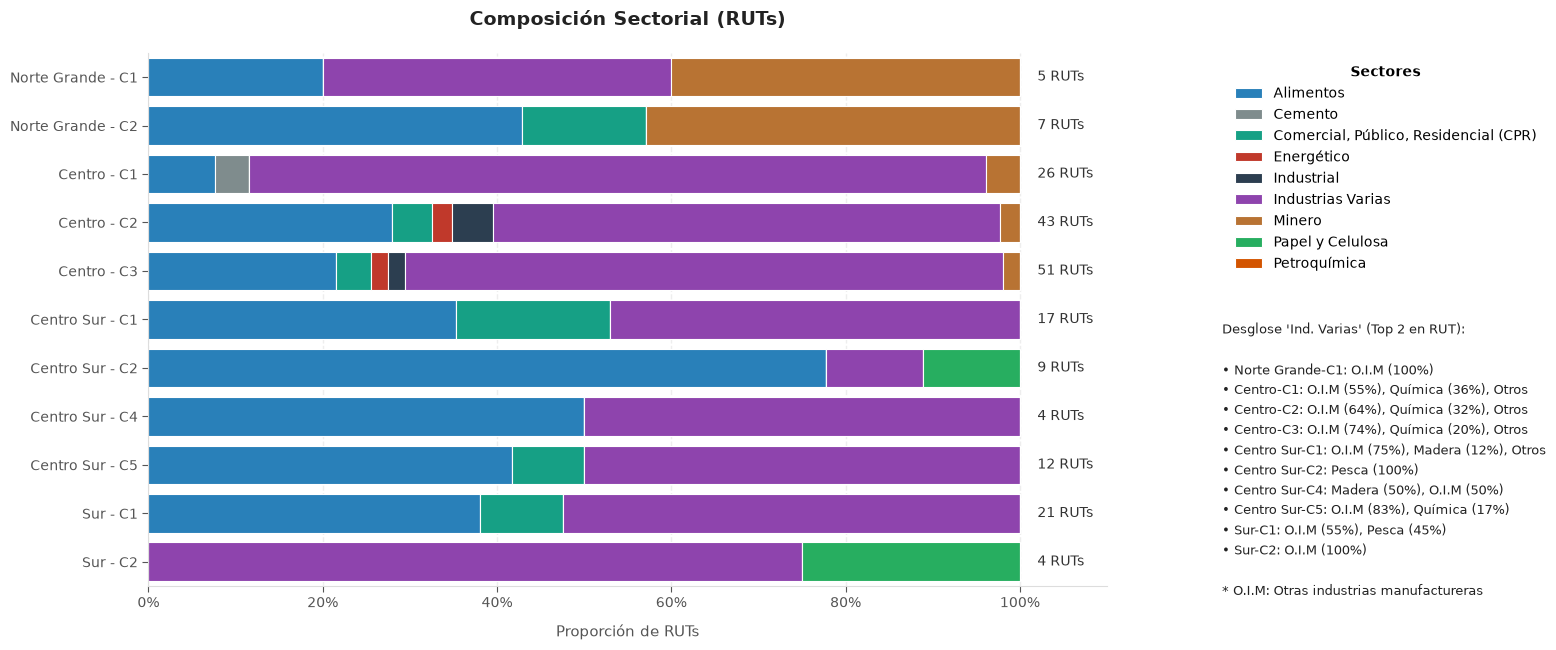

In [14]:

graficar_composicion_sectorial_filtrado(
    df=df, # <-- Tu dataframe normal de clústeres
    col_proporciones='sect_rut_cluster',
    col_totales='total_rut_cluster',
    sufijo_total='RUTs',
    titulo="Composición Sectorial (RUTs)",
    xlabel="Proporción de RUTs",
    formato_cientifico=False,
    clusters_interes=clusters_target,
    df_dt=df_dt,               # <-- Pasas la base de datos completa con perfiles horarios
    tipo_calculo='RUT'     # <-- Le avisas que debe calcular en base a (medida_total * medida_count)
)

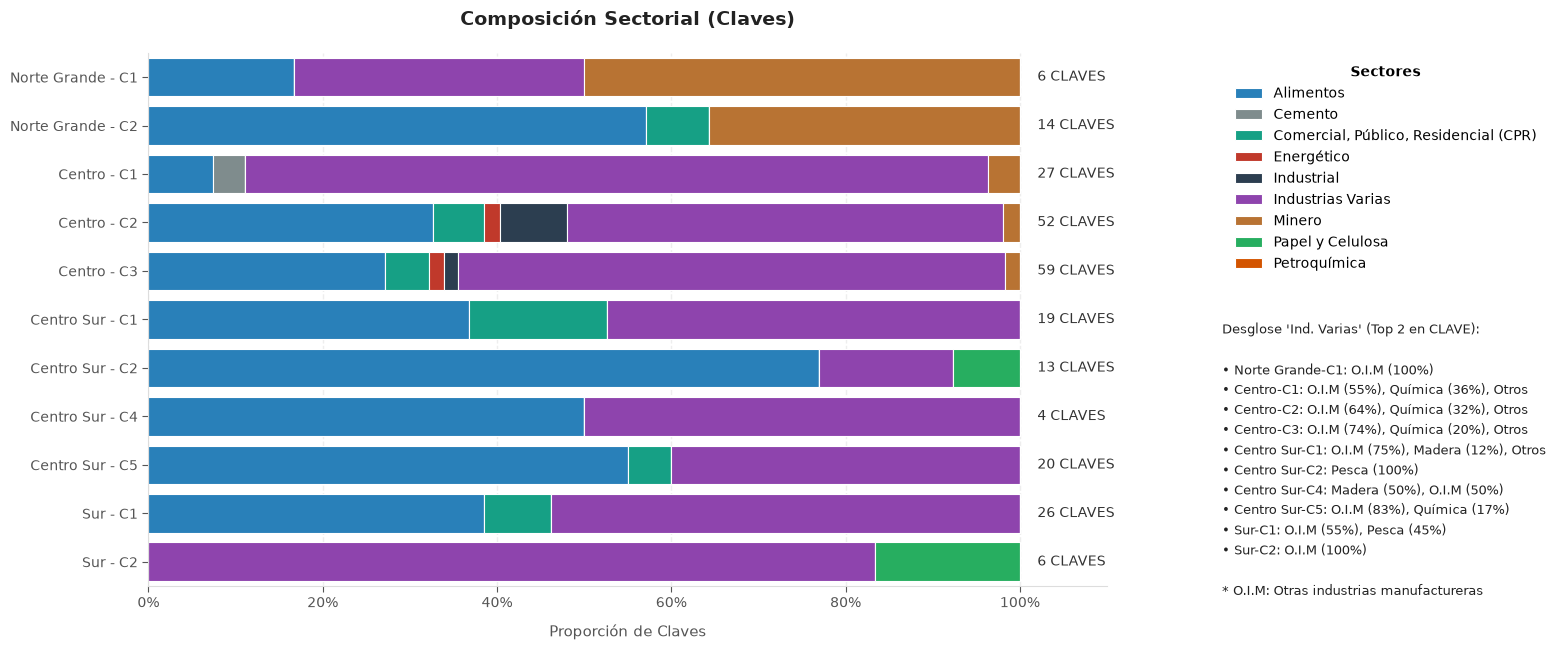

In [ ]:

graficar_composicion_sectorial_filtrado(
    df=df, # <-- Tu dataframe normal de clústeres
    col_proporciones='sect_claves_cluster',
    col_totales='total_claves_cluster',
    sufijo_total='CLAVES',
    titulo="Composición Sectorial (Claves)",
    xlabel="Proporción de Claves",
    formato_cientifico=False,
    clusters_interes=clusters_target,
    df_dt=df_dt,               
    tipo_calculo='CLAVE'     
)

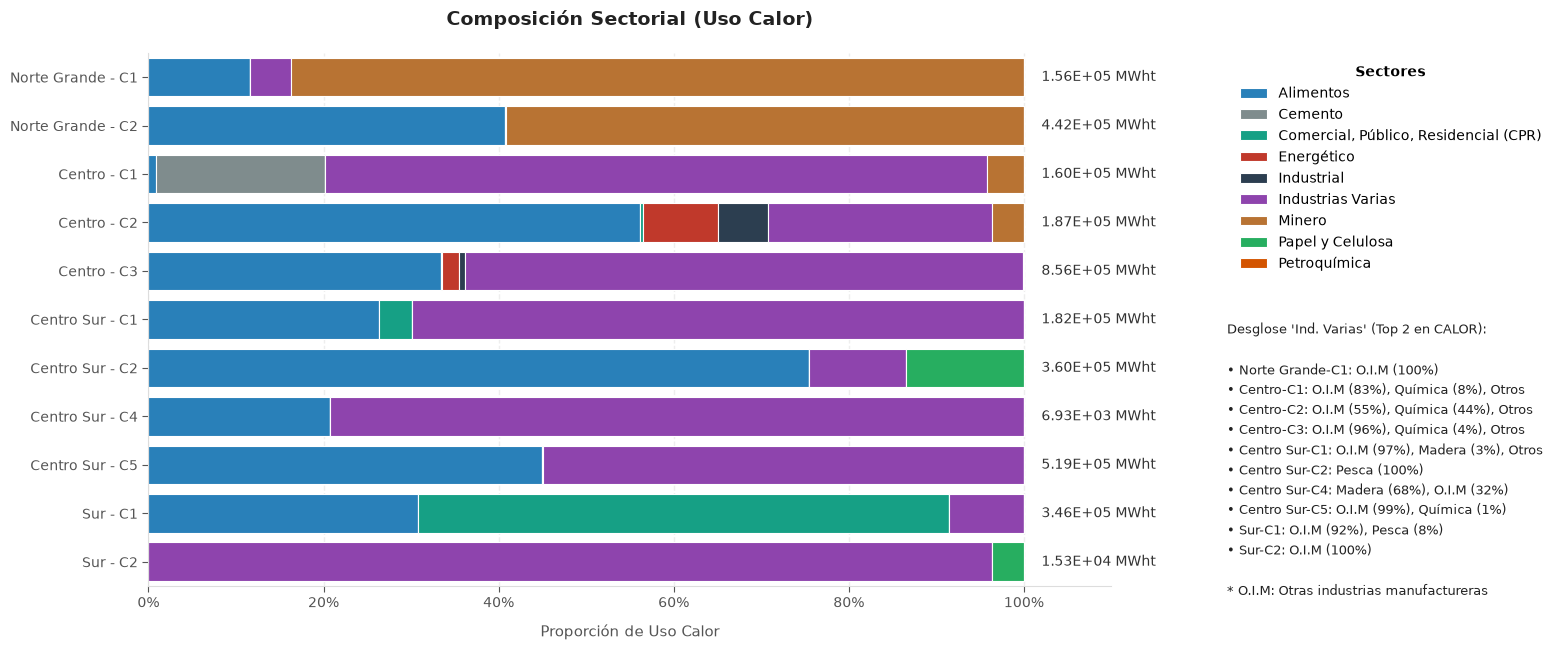

In [17]:

graficar_composicion_sectorial_filtrado(
    df=df, # <-- Tu dataframe normal de clústeres
    col_proporciones='sect_calor_cluster',
    col_totales='total_calor_cluster_mwh',
    sufijo_total='MWht',
    titulo="Composición Sectorial (Uso Calor)",
    xlabel="Proporción de Uso Calor",
    formato_cientifico=True,
    clusters_interes=clusters_target,
    df_dt=df_dt,               # <-- Pasas la base de datos completa con perfiles horarios
    tipo_calculo='CALOR'     # <-- Le avisas que debe calcular en base a (medida_total * medida_count)
)

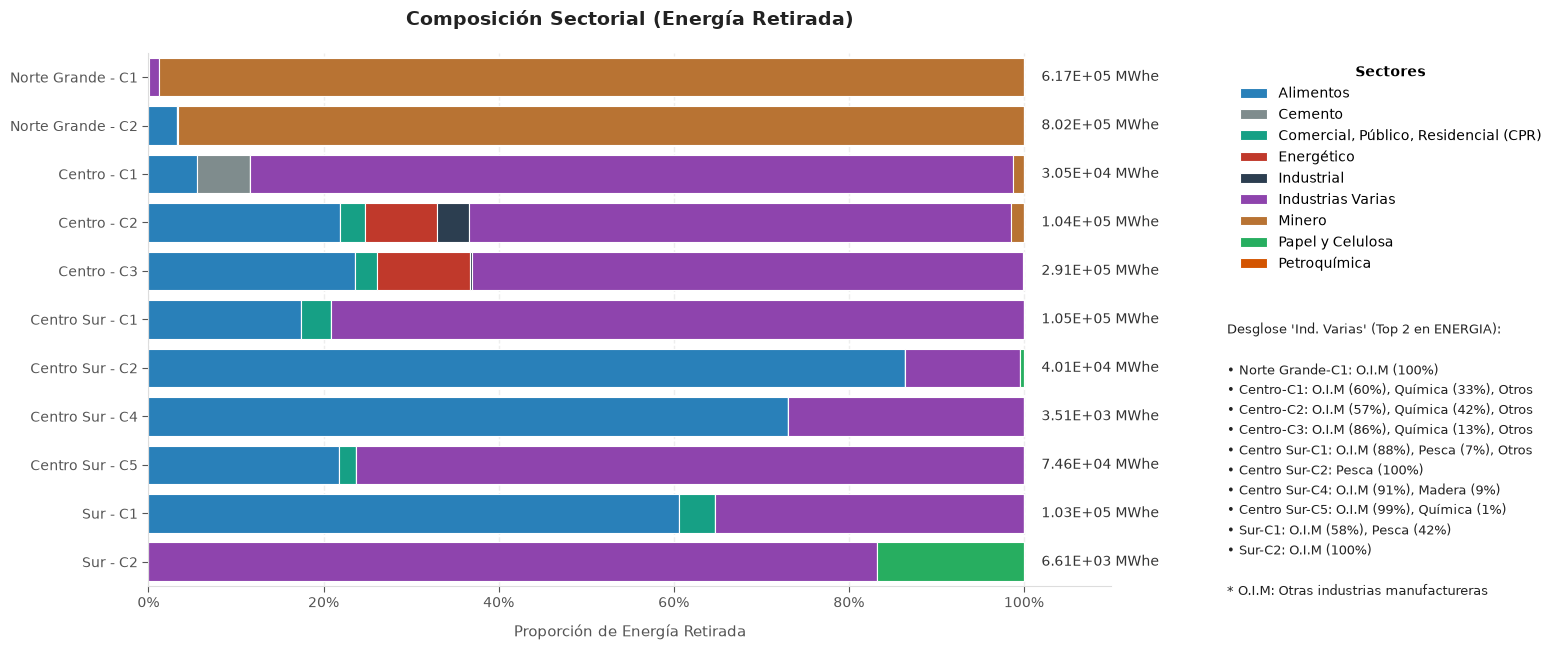

In [18]:

graficar_composicion_sectorial_filtrado(
    df=df, # <-- Tu dataframe normal de clústeres
    col_proporciones='sect_energia_cluster',
    col_totales='total_energia_cluster_mwh',
    sufijo_total='MWhe',
    titulo="Composición Sectorial (Energía Retirada)",
    xlabel="Proporción de Energía Retirada",
    formato_cientifico=True,
    clusters_interes=clusters_target,
    df_dt=df_dt,               # <-- Pasas la base de datos completa con perfiles horarios
    tipo_calculo='ENERGIA'     # <-- Le avisas que debe calcular en base a (medida_total * medida_count)
)

In [6]:
df_dt.columns

Index(['clave', 'RUT_CLIENTE', 'REGION_CLIENTE', 'macrozona', 'Zona', 'Hora',
       'medida_count', 'medida_min', 'CLIENTE', 'CLIENTE_log', 'n_clientes',
       'TIPO', 'NOMBRE_ESTABLECIMIENTO', 'SECTOR', 'SUBSECTOR', 'RUBRO',
       'DEMANDA_CALOR_MWH_sum', 'DEMANDA_CALOR_MWH_mean',
       'DEMANDA_CALOR_MWH_std', 'DEMANDA_CALOR_MWH_max',
       'DEMANDA_CALOR_MWH_min', 'RUT_PROVEEDOR', 'RUT_PROVEEDOR_log',
       'n_rut_proveedores', 'PROVEEDOR', 'PROVEEDOR_log', 'n_proveedores',
       'nombre_barra', 'nombre_barra_log', 'n_nombres_barra', 'tension',
       'tension_log', 'n_tensiones', 'Nombre_Corto', 'Nombre_Corto_log',
       'n_nombres_cortos', 'periodo_last', 'periodos_log', 'meses_operados',
       'medida_mean', 'medida_std', 'CMg[CLP/KWh]_mean', 'CMg[CLP/KWh]_std',
       'CMg[CLP/KWh]_count', 'valorizado_CLP_mean', 'valorizado_CLP_std',
       'valorizado_CLP_count', 'medida_total', 'medida_porcentual',
       'clave_unica', 'id_cluster', 'metodo_cluster', 'dtw_window',
  

In [ ]:
import pandas as pd

# ==========================================
# 1. BATERÍAS CARGABLES (Oferta posible)
# ==========================================
# Un RUT puede tener varias claves (instalaciones). 
# Eliminamos duplicados a nivel de clave y SUMAMOS las baterías de todas ellas.
baterias_cargables_por_rut = df_dt.drop_duplicates(
    subset=["RUT_CLIENTE", "REGION_CLIENTE", "clave_unica", "macrozona"]
).groupby(["RUT_CLIENTE", "REGION_CLIENTE", "macrozona"]).agg(
    baterias_cargables_por_rut=('n_baterias_cargadas', 'sum')
).reset_index()

# ==========================================
# 2. BATERÍAS REQUERIDAS (Demanda de calor)
# ==========================================
# Hay 1 sola demanda de calor por RUT/Región.
# Aislamos ese registro único y tomamos su valor.
baterias_requeridas_por_rut = df_dt.drop_duplicates(
    subset=["RUT_CLIENTE", "REGION_CLIENTE", "macrozona"]
).groupby(["RUT_CLIENTE", "REGION_CLIENTE", "macrozona"]).agg(
    # Usamos 'first' en lugar de 'sum' porque es un valor único constante por RUT
    baterias_requeridas_por_rut=('n_baterias_requeridas', 'first') 
).reset_index()

# ==========================================
# 3. CÁLCULO DEL MERCADO FACTIBLE
# ==========================================
# Cruzamos ambas tablas conservando todos los RUTs (outer join)
mercado_por_rut = pd.merge(
    baterias_cargables_por_rut, 
    baterias_requeridas_por_rut, 
    on=["RUT_CLIENTE", "REGION_CLIENTE", "macrozona"], 
    how="outer"
).fillna(0) # Si un RUT solo requería pero no podía cargar (o viceversa), rellenamos con 0

# La cantidad final a vender es la restricción entre lo que puede cargar y lo que requiere
mercado_por_rut["demanda_baterias"] = mercado_por_rut[["baterias_cargables_por_rut", "baterias_requeridas_por_rut"]].min(axis=1)

# Verificamos los resultados
mercado_por_rut.head()

50

findfont: Failed to find font weight 500, now using 400.


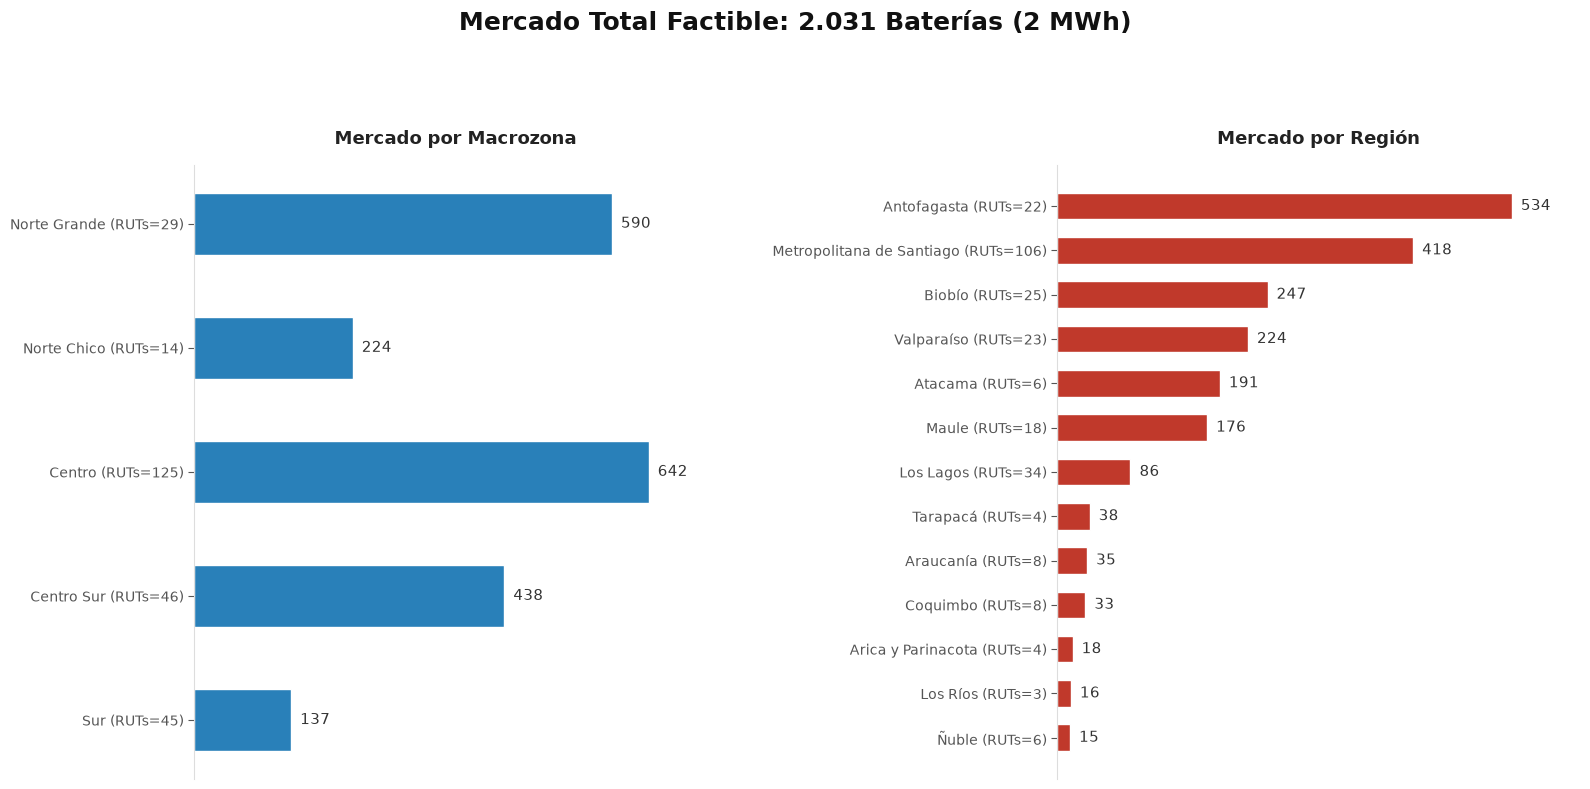

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def graficar_mercado_total(df_mercado):
    # ==========================================
    # 1. PREPARACIÓN DE DATOS Y CÁLCULO DEL TOTAL
    # ==========================================
    # NUEVO: Filtramos localmente para no afectar el dataframe original fuera de la función.
    # Solo consideramos clientes con demanda factible mayor a 0.
    df_filtrado = df_mercado[df_mercado['demanda_baterias'] > 0].copy()
    
    total_mercado = df_filtrado['demanda_baterias'].sum()
    total_str = f"{int(total_mercado):,}".replace(",", ".")
    
    # Agrupación por Macrozona usando el dataframe filtrado
    df_macro = df_filtrado.groupby('macrozona', observed=False).agg(
        demanda_baterias=('demanda_baterias', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    df_macro['macrozona'] = pd.Categorical(df_macro['macrozona'], categories=orden_macrozonas, ordered=True)
    df_macro = df_macro.sort_values('macrozona').reset_index(drop=True)
    
    # Crear la etiqueta combinada para Macrozona
    etiquetas_macro = df_macro['macrozona'].astype(str) + " (RUTs=" + df_macro['total_ruts'].astype(str) + ")"

    # Agrupación por Región usando el dataframe filtrado
    df_region = df_filtrado.groupby('REGION_CLIENTE').agg(
        demanda_baterias=('demanda_baterias', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    df_region = df_region.sort_values('demanda_baterias', ascending=True).reset_index(drop=True)
    
    # Crear la etiqueta combinada para Región
    etiquetas_region = df_region['REGION_CLIENTE'].astype(str) + " (RUTs=" + df_region['total_ruts'].astype(str) + ")"

    # ==========================================
    # 2. CONFIGURACIÓN DEL LIENZO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    color_macro = '#2980B9'
    color_region = '#C0392B'

    # ==========================================
    # 3. GRÁFICO 1: POR MACROZONA
    # ==========================================
    ax1 = axes[0]
    barras_macro = ax1.barh(etiquetas_macro, df_macro['demanda_baterias'], 
                            height=0.5, color=color_macro, edgecolor='white')
    
    ax1.invert_yaxis()
    
    max_macro = df_macro['demanda_baterias'].max()
    ax1.set_xlim(0, max_macro * 1.15)
    
    for barra in barras_macro:
        ancho = barra.get_width()
        if ancho > 0:
            texto = f"{int(ancho):,}".replace(",", ".")
            ax1.text(ancho + (max_macro * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=11, color='#333333', fontweight='500')

    ax1.set_title("Mercado por Macrozona", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_color('#dddddd')
    ax1.get_xaxis().set_visible(False)
    ax1.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 4. GRÁFICO 2: POR REGIÓN
    # ==========================================
    ax2 = axes[1]
    barras_region = ax2.barh(etiquetas_region, df_region['demanda_baterias'], 
                             height=0.6, color=color_region, edgecolor='white')
    
    max_region = df_region['demanda_baterias'].max()
    ax2.set_xlim(0, max_region * 1.15)
    
    for barra in barras_region:
        ancho = barra.get_width()
        if ancho > 0:
            texto = f"{int(ancho):,}".replace(",", ".")
            ax2.text(ancho + (max_region * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=11, color='#333333', fontweight='500')

    ax2.set_title("Mercado por Región", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_color('#dddddd')
    ax2.get_xaxis().set_visible(False)
    ax2.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 5. SUPER TÍTULO (TOTAL) Y AJUSTE FINAL
    # ==========================================
    titulo_principal = f"Mercado Total Factible: {total_str} Baterías (2 MWh)"
    fig.suptitle(titulo_principal, color='#111111', fontsize=18, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.90], w_pad=4)
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
graficar_mercado_total(mercado_por_rut)

findfont: Failed to find font weight 500, now using 400.


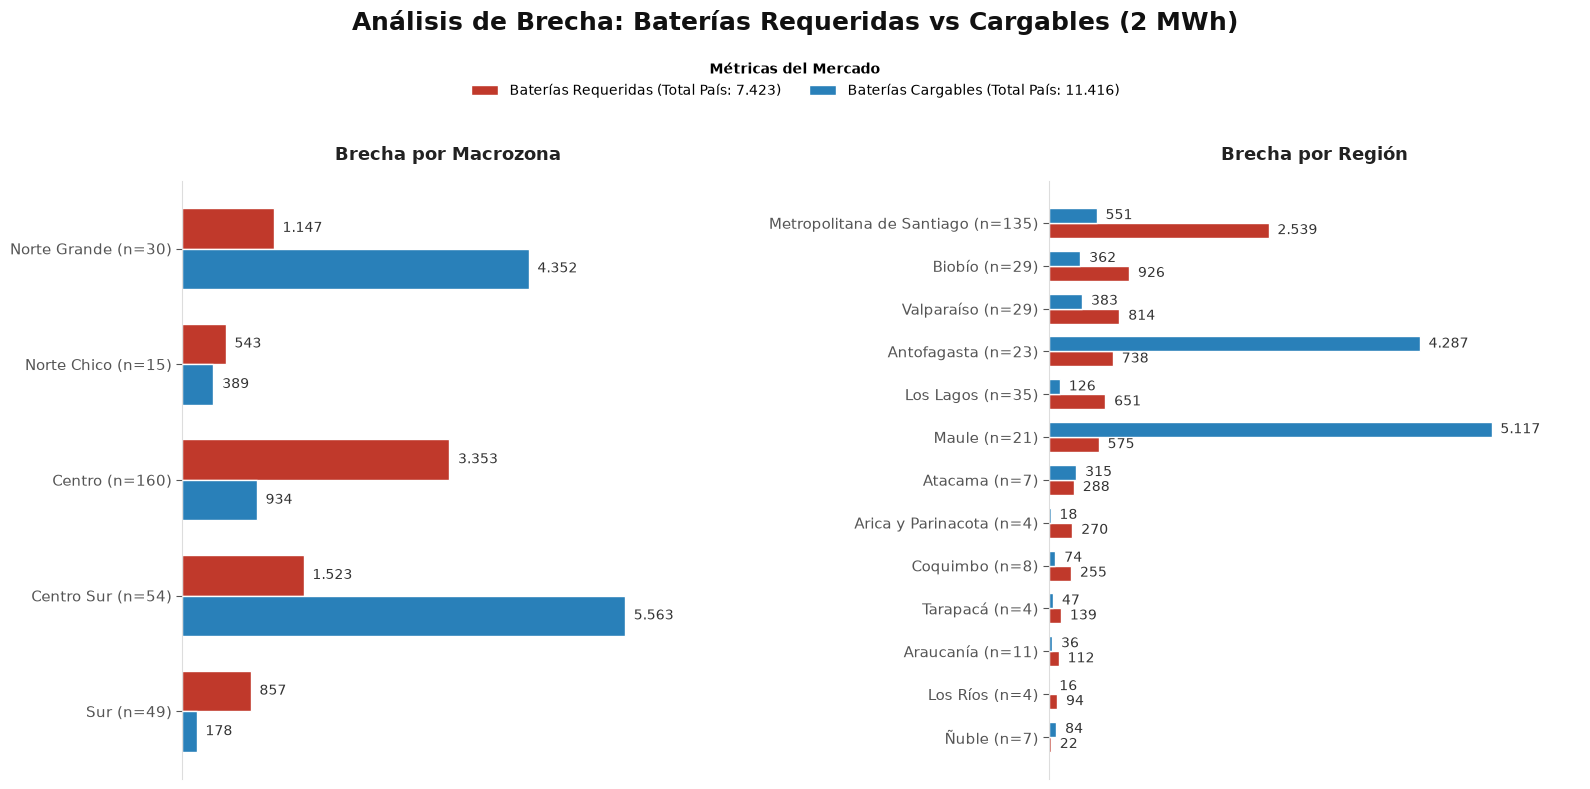

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def graficar_brecha_mercado(df_mercado):
    # ==========================================
    # 1. CÁLCULO DE TOTALES GLOBALES (NUEVO)
    # ==========================================
    total_requeridas = df_mercado['baterias_requeridas_por_rut'].sum()
    total_cargables = df_mercado['baterias_cargables_por_rut'].sum()
    
    # Formato con separador de miles
    str_req = f"{int(total_requeridas):,}".replace(",", ".")
    str_carg = f"{int(total_cargables):,}".replace(",", ".")

    # ==========================================
    # 2. PREPARACIÓN DE DATOS
    # ==========================================
    # Agrupación por Macrozona
    df_macro = df_mercado.groupby('macrozona', observed=False).agg(
        requeridas=('baterias_requeridas_por_rut', 'sum'),
        cargables=('baterias_cargables_por_rut', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
    df_macro['macrozona'] = pd.Categorical(df_macro['macrozona'], categories=orden_macrozonas, ordered=True)
    df_macro = df_macro.sort_values('macrozona').reset_index(drop=True)
    etiquetas_macro = df_macro['macrozona'].astype(str) + " (n=" + df_macro['total_ruts'].astype(str) + ")"

    # Agrupación por Región
    df_region = df_mercado.groupby('REGION_CLIENTE').agg(
        requeridas=('baterias_requeridas_por_rut', 'sum'),
        cargables=('baterias_cargables_por_rut', 'sum'),
        total_ruts=('RUT_CLIENTE', 'nunique')
    ).reset_index()
    
    df_region = df_region.sort_values('requeridas', ascending=True).reset_index(drop=True)
    etiquetas_region = df_region['REGION_CLIENTE'].astype(str) + " (n=" + df_region['total_ruts'].astype(str) + ")"

    # ==========================================
    # 3. CONFIGURACIÓN DEL LIENZO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(df_region) * 0.5)))
    
    color_req = '#C0392B'
    color_carg = '#2980B9'
    alto_barra = 0.35

    def agregar_textos(ax, barras, max_val):
        for barra in barras:
            ancho = barra.get_width()
            if ancho > 0:
                texto = f"{int(ancho):,}".replace(",", ".")
                ax.text(ancho + (max_val * 0.02), barra.get_y() + barra.get_height()/2, 
                        texto, va='center', ha='left', fontsize=10, color='#333333', fontweight='500')

    # ==========================================
    # 4. GRÁFICO 1: COMPARACIÓN POR MACROZONA
    # ==========================================
    ax1 = axes[0]
    y_pos_macro = np.arange(len(df_macro))
    
    # NUEVO: Inyectamos los totales calculados en el parámetro 'label'
    label_req_con_total = f'Baterías Requeridas (Total País: {str_req})'
    label_carg_con_total = f'Baterías Cargables (Total País: {str_carg})'

    barras_req_m = ax1.barh(y_pos_macro - alto_barra/2, df_macro['requeridas'], 
                            alto_barra, label=label_req_con_total, color=color_req, edgecolor='white')
    barras_carg_m = ax1.barh(y_pos_macro + alto_barra/2, df_macro['cargables'], 
                             alto_barra, label=label_carg_con_total, color=color_carg, edgecolor='white')
    
    max_macro = max(df_macro['requeridas'].max(), df_macro['cargables'].max())
    ax1.set_xlim(0, max_macro * 1.20)
    
    agregar_textos(ax1, barras_req_m, max_macro)
    agregar_textos(ax1, barras_carg_m, max_macro)

    ax1.set_yticks(y_pos_macro)
    ax1.set_yticklabels(etiquetas_macro, color='#333333', fontsize=11)
    ax1.invert_yaxis()
    
    ax1.set_title("Brecha por Macrozona", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_color('#dddddd')
    ax1.get_xaxis().set_visible(False)
    ax1.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 5. GRÁFICO 2: COMPARACIÓN POR REGIÓN
    # ==========================================
    ax2 = axes[1]
    y_pos_region = np.arange(len(df_region))
    
    barras_req_r = ax2.barh(y_pos_region - alto_barra/2, df_region['requeridas'], 
                            alto_barra, color=color_req, edgecolor='white')
    barras_carg_r = ax2.barh(y_pos_region + alto_barra/2, df_region['cargables'], 
                             alto_barra, color=color_carg, edgecolor='white')
    
    max_region = max(df_region['requeridas'].max(), df_region['cargables'].max())
    ax2.set_xlim(0, max_region * 1.20)
    
    agregar_textos(ax2, barras_req_r, max_region)
    agregar_textos(ax2, barras_carg_r, max_region)

    ax2.set_yticks(y_pos_region)
    ax2.set_yticklabels(etiquetas_region, color='#333333', fontsize=11)
    
    ax2.set_title("Brecha por Región", color='#222222', fontsize=13, fontweight='bold', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_color('#dddddd')
    ax2.get_xaxis().set_visible(False)
    ax2.tick_params(axis='y', colors='#555555', length=4)

    # ==========================================
    # 6. SUPER TÍTULO Y LEYENDA GLOBAL
    # ==========================================
    fig.suptitle("Análisis de Brecha: Baterías Requeridas vs Cargables (2 MWh)", 
                 color='#111111', fontsize=18, fontweight='bold', y=0.98)

    # La leyenda ahora tomará automáticamente los textos con los totales que le pusimos a las barras
    fig.legend(handles=[barras_req_m, barras_carg_m], loc='upper center', 
               bbox_to_anchor=(0.5, 0.93), ncol=2, frameon=False, 
               title='Métricas del Mercado', title_fontproperties={'weight': 'bold'})

    plt.tight_layout(rect=[0, 0, 1, 0.88], w_pad=4)
    plt.show()

# ==========================================
# EJECUCIÓN
# ==========================================
graficar_brecha_mercado(mercado_por_rut)

In [ ]:
baterias_cargables_clusters = df_dt.drop_duplicates(subset=['clave_unica', 'macrozona', 'id_cluster']).groupby(['macrozona', 'id_cluster'])['n_baterias_cargadas'].sum().reset_index(name='baterias_cargadas')
baterias_requeridas = df_dt.drop_duplicates(subset=["RUT_CLIENTE", "REGION_CLIENTE", "macrozona", "id_cluster"]).groupby(['macrozona', 'id_cluster'])['n_baterias_requeridas'].sum().reset_index(name='baterias_requeridas')
ruts_clusters = df_dt.drop_duplicates(subset=["RUT_CLIENTE", "REGION_CLIENTE", "macrozona", "id_cluster"]).groupby(['macrozona', 'id_cluster'])['RUT_CLIENTE'].nunique().reset_index(name='total_rut_cluster')  



# ==========================================
# 1. PREPARACIÓN Y UNIÓN DE LOS DATOS
# ==========================================
# (Asumiendo que ya corriste tu código para generar baterias_cargables_clusters y baterias_requeridas)

# Unimos ambos dataframes por macrozona e id_cluster
df_baterias = pd.merge(
    baterias_cargables_clusters, 
    baterias_requeridas, 
    on=['macrozona', 'id_cluster'], 
    how='outer'
).fillna(0)
df_baterias = pd.merge(df_baterias, ruts_clusters, on=['macrozona', 'id_cluster'], how='outer')
df_baterias["baterias_cargadas_por_rut"] = df_baterias["baterias_cargadas"] / df_baterias["total_rut_cluster"]
df_baterias["baterias_requeridas_por_rut"] = df_baterias["baterias_requeridas"] / df_baterias["total_rut_cluster"]

# Ordenamos por las macrozonas establecidas
orden_macrozonas = ['Norte Grande', 'Norte Chico', 'Centro', 'Centro Sur', 'Sur']
df_baterias['macrozona'] = pd.Categorical(df_baterias['macrozona'], categories=orden_macrozonas, ordered=True)
df_baterias = df_baterias.sort_values(['macrozona', 'id_cluster']).reset_index(drop=True)


In [55]:
def graficar_comparacion_baterias(df, 
                                  titulo="Comparación de Baterías Cargadas vs Requeridas por Clúster", 
                                  formato_cientifico=False,
                                  normalizado=False):
    
    # --- CONFIGURACIÓN INICIAL ---
    fig, ax = plt.subplots(figsize=(11, max(6, len(df) * 0.42)))
    
    if normalizado and 'total_rut_cluster' in df.columns:
        ruts_str = df['total_rut_cluster'].fillna(0).astype(int).astype(str)
        y_labels = df['macrozona'].astype(str) + " - C" + df['id_cluster'].astype(str) + " (n=" + ruts_str + " RUTs)"
    else:
        y_labels = df['macrozona'].astype(str) + " - C" + df['id_cluster'].astype(str)
        
    y_pos = np.arange(len(df))
    alto_barra = 0.35 
    
    # --- LÓGICA DE NORMALIZACIÓN ---
    if normalizado:
        col_req = 'baterias_requeridas_por_rut'
        col_carg = 'baterias_cargadas_por_rut'
        label_req = 'Requeridas por RUT (2 MWh)'
        label_carg = 'Cargadas por RUT (2 MWh)'
        if titulo == "Comparación de Baterías Cargadas vs Requeridas por Clúster":
            titulo += " (Normalizado por RUT)"
    else:
        col_req = 'baterias_requeridas'
        col_carg = 'baterias_cargadas'
        label_req = 'Baterías Requeridas (2 MWh)'
        label_carg = 'Baterías Cargadas (2 MWh)'

    # --- GENERACIÓN DEL GRÁFICO ---
    barras_req = ax.barh(y_pos - alto_barra/2, df[col_req], 
                         alto_barra, label=label_req, 
                         color='#C0392B', edgecolor='white', linewidth=0.8) 
    
    barras_carg = ax.barh(y_pos + alto_barra/2, df[col_carg], 
                          alto_barra, label=label_carg, 
                          color='#2980B9', edgecolor='white', linewidth=0.8) 
    
    max_val = max(df[col_req].max(), df[col_carg].max())
    ax.set_xlim(0, max_val * 1.15) 
    
    # --- ETIQUETAS DE TEXTO EN LAS BARRAS ---
    def agregar_textos(barras):
        for barra in barras:
            ancho = barra.get_width()
            if ancho > 0: 
                if formato_cientifico:
                    texto = f"{ancho:.2E}"
                elif normalizado:
                    texto = f"{ancho:.2f}" 
                else:
                    texto = f"{int(ancho):,}".replace(",", ".")
                
                ax.text(ancho + (max_val * 0.01), barra.get_y() + barra.get_height()/2, 
                        texto, va='center', ha='left', fontsize=9.5, color='#333333', fontweight='500')

    agregar_textos(barras_req)
    agregar_textos(barras_carg)
    
    # --- ESTILOS Y FORMATO FINAL ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
    ax.invert_yaxis()  

    # Limpiar bordes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False) 
    ax.spines['left'].set_color('#dddddd')
    
    ax.get_xaxis().set_visible(False) 
    ax.tick_params(axis='y', colors='#555555', length=4) 

    # ==========================================
    # CORRECCIÓN DE CENTRADO (TÍTULO Y LEYENDA)
    # ==========================================
    # 1. fig.suptitle centra el título respecto al ancho total de la imagen
    fig.suptitle(titulo, color='#222222', fontsize=14, fontweight='bold', y=0.98)

    # 2. fig.legend hace lo mismo con la leyenda, colocándola justo bajo el título
    fig.legend(handles=[barras_req, barras_carg], 
               loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=2, 
               frameon=False, title='Estado de Baterías', title_fontproperties={'weight': 'bold'})

    # 3. Usamos 'rect' en tight_layout para decirle que reserve el 10% superior 
    # de la imagen exclusivamente para el título y la leyenda (evita que se superpongan)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    plt.show()

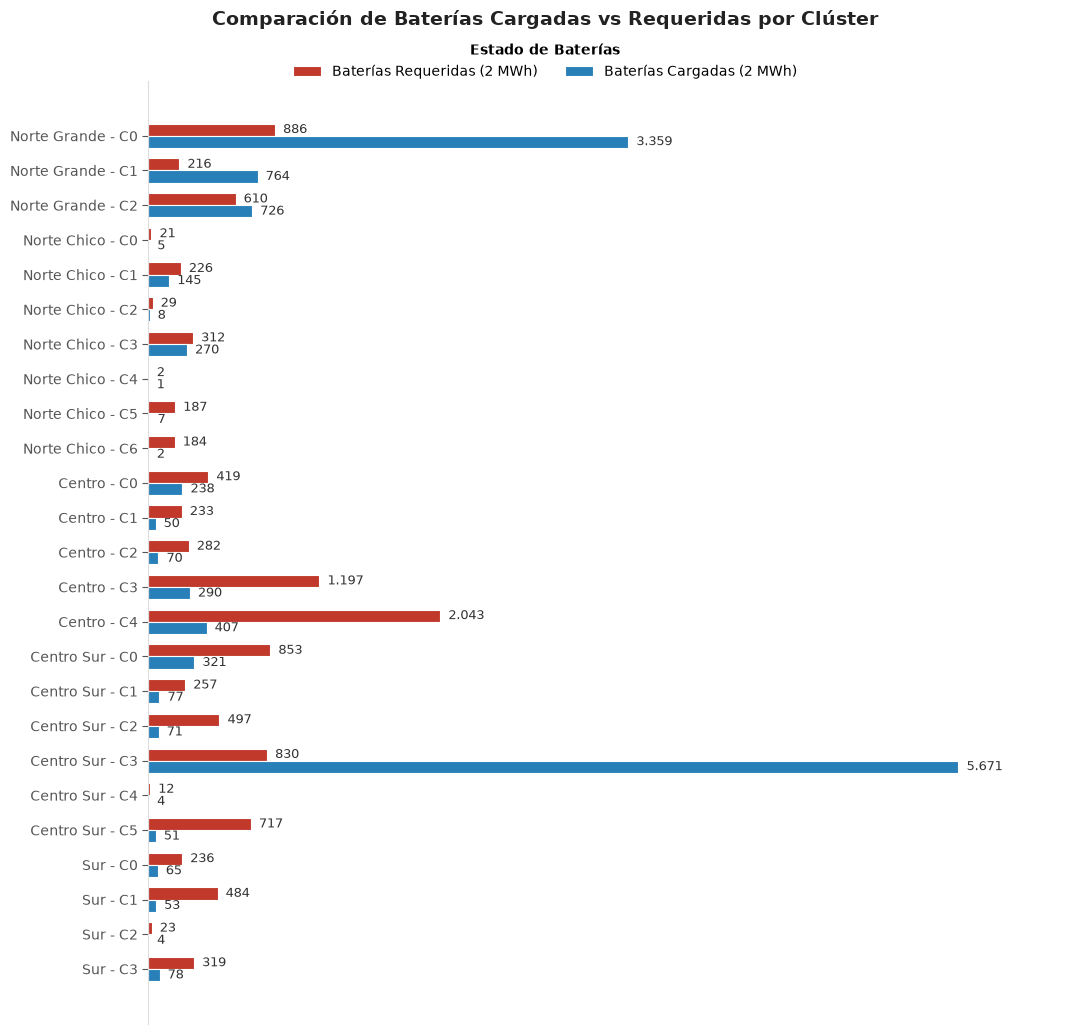

In [56]:
graficar_comparacion_baterias(df_baterias, normalizado=False)

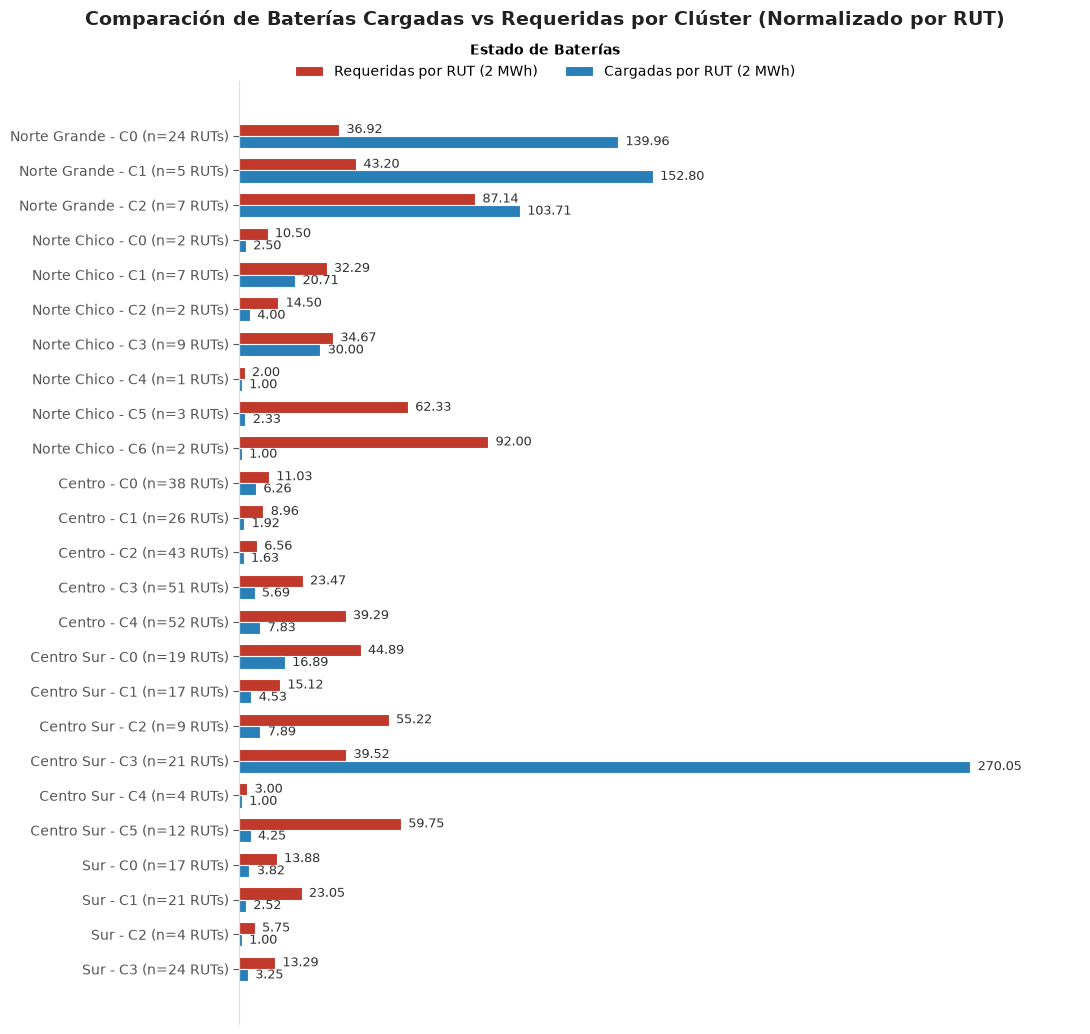

In [57]:
graficar_comparacion_baterias(df_baterias, normalizado=True)

In [63]:
df_dt.columns

Index(['clave', 'RUT_CLIENTE', 'REGION_CLIENTE', 'macrozona', 'Zona', 'Hora',
       'medida_count', 'medida_min', 'CLIENTE', 'CLIENTE_log', 'n_clientes',
       'TIPO', 'NOMBRE_ESTABLECIMIENTO', 'SECTOR', 'SUBSECTOR', 'RUBRO',
       'DEMANDA_CALOR_MWH_sum', 'DEMANDA_CALOR_MWH_mean',
       'DEMANDA_CALOR_MWH_std', 'DEMANDA_CALOR_MWH_max',
       'DEMANDA_CALOR_MWH_min', 'RUT_PROVEEDOR', 'RUT_PROVEEDOR_log',
       'n_rut_proveedores', 'PROVEEDOR', 'PROVEEDOR_log', 'n_proveedores',
       'nombre_barra', 'nombre_barra_log', 'n_nombres_barra', 'tension',
       'tension_log', 'n_tensiones', 'Nombre_Corto', 'Nombre_Corto_log',
       'n_nombres_cortos', 'periodo_last', 'periodos_log', 'meses_operados',
       'medida_mean', 'medida_std', 'CMg[CLP/KWh]_mean', 'CMg[CLP/KWh]_std',
       'CMg[CLP/KWh]_count', 'valorizado_CLP_mean', 'valorizado_CLP_std',
       'valorizado_CLP_count', 'medida_total', 'medida_porcentual',
       'clave_unica', 'id_cluster', 'metodo_cluster', 'dtw_window',
  

In [8]:
precio_dolar = 926.41

# ==========================================
# 1. AGRUPACIÓN (Promedio del Costo Térmico)
# ==========================================
# Usamos 'costo_MWht_bateria' que ya trae los CLP por cada MWh TÉRMICO útil
df_agrupado = df_dt.drop_duplicates(subset=['clave_unica', 'macrozona', 'id_cluster'])\
                   .groupby(['macrozona', 'id_cluster'])['costo_MWht_bateria']\
                   .mean().reset_index()

# ==========================================
# 2. CONVERSIÓN A USD
# ==========================================
# Convertimos de CLP/MWht a USD/MWht
df_agrupado['costo_usd_mwht'] = df_agrupado['costo_MWht_bateria'] / precio_dolar

# ==========================================
# 3. ORDENAMIENTO PARA EL GRÁFICO
# ==========================================
# Ordenamos primero por macrozona, y luego por costo (de menor a mayor) 
# para que las barras queden con la opción más barata arriba.
orden_macrozonas = ["Norte Grande", "Norte Chico", "Centro", "Centro Sur", "Sur"]
df_agrupado['macrozona'] = pd.Categorical(df_agrupado['macrozona'], categories=orden_macrozonas, ordered=True)

df_agrupado = df_agrupado.sort_values(by=['macrozona', 'costo_usd_mwht'], ascending=[True, True]).reset_index(drop=True)

findfont: Failed to find font weight 500, now using 400.


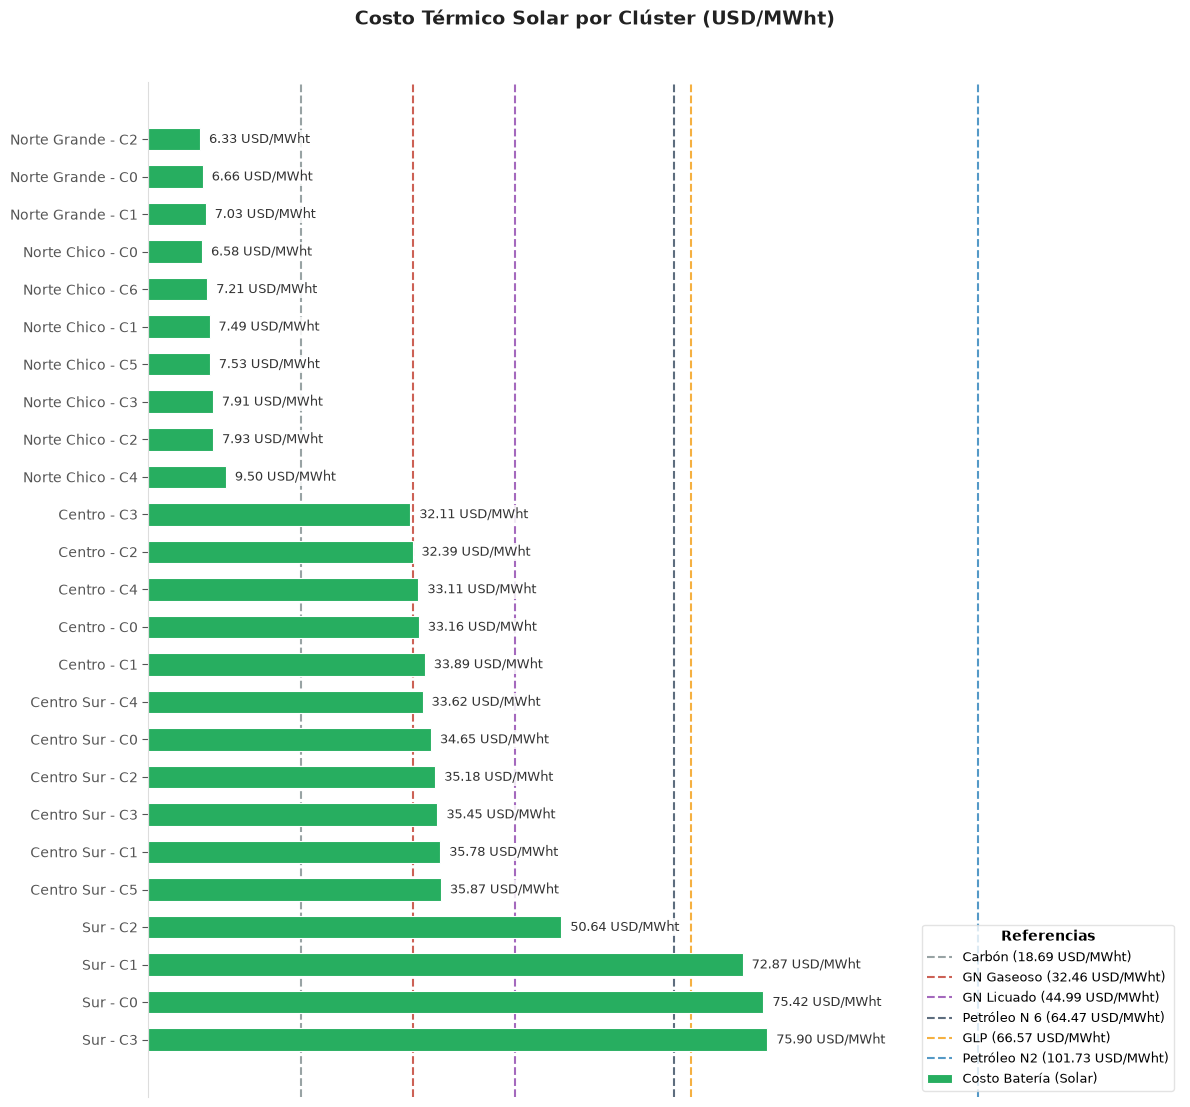

In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def graficar_costo_solar(df, titulo="Costo Térmico Solar por Clúster (USD/MWht)", mostrar_referencias=True):
    
    # --- ORDENAMIENTO GEOGRÁFICO ---
    orden_macrozonas = ["Norte Grande", "Norte Chico", "Centro", "Centro Sur", "Sur"]
    df_plot = df.copy()
    df_plot['macrozona'] = pd.Categorical(df_plot['macrozona'], categories=orden_macrozonas, ordered=True)
    
    # Ordenamos por macrozona y luego por costo de menor a mayor (el más barato arriba)
    df_plot = df_plot.sort_values(by=['macrozona', 'costo_usd_mwht'], ascending=[True, True]).reset_index(drop=True)

    # --- CONFIGURACIÓN INICIAL ---
    fig, ax = plt.subplots(figsize=(12, max(6, len(df_plot) * 0.45)))
    
    y_labels = df_plot['macrozona'].astype(str) + " - C" + df_plot['id_cluster'].astype(str)
    y_pos = np.arange(len(df_plot))
    alto_barra = 0.6 
    
    # --- GENERACIÓN DEL GRÁFICO ---
    barras = ax.barh(y_pos, df_plot['costo_usd_mwht'], 
                     alto_barra, label='Costo Batería (Solar)', 
                     color='#27AE60', edgecolor='white', linewidth=0.8) 
    
    # --- REFERENCIAS DE TODOS LOS COMBUSTIBLES ---
    if mostrar_referencias:
        # Nuevos valores de costo en USD/MWht
        referencias = {
            'Carbón (18.69 USD/MWht)': (18.69, '#7F8C8D'),          # Gris
            'GN Gaseoso (32.46 USD/MWht)': (32.46, '#C0392B'),      # Rojo Fuerte
            'GN Licuado (44.99 USD/MWht)': (44.99, '#8E44AD'),      # Púrpura
            'Petróleo N 6 (64.47 USD/MWht)': (64.47, '#34495E'),    # Azul Marino Oscuro
            'GLP (66.57 USD/MWht)': (66.57, '#F39C12'),             # Naranja
            'Petróleo N2 (101.73 USD/MWht)': (101.73, '#2980B9')    # Azul Claro (Diesel)
        }
        
        for nombre, (valor, color) in referencias.items():
            ax.axvline(x=valor, color=color, linestyle='--', alpha=0.8, zorder=0, label=nombre)
            
    # Ajustamos el límite máximo para que el Petróleo N2 (101.73) siempre quepa en el gráfico
    max_val = max(df_plot['costo_usd_mwht'].max(), 110 if mostrar_referencias else 0)
    ax.set_xlim(0, max_val * 1.15) 
    
    # --- ETIQUETAS DE TEXTO EN LAS BARRAS ---
    for barra in barras:
        ancho = barra.get_width()
        
        if ancho > 0: 
            texto = f"{ancho:.2f} USD/MWht"
            pos_x = ancho + (max_val * 0.01)
            
            # Aplicamos el escudo blanco (bbox) detrás del texto para que no se raye con las líneas
            ax.text(pos_x, barra.get_y() + barra.get_height()/2, 
                    texto, va='center', ha='left', fontsize=9.5, color='#333333', fontweight='500',
                    bbox=dict(facecolor='white', edgecolor='none', alpha=0.85, pad=1.5))

    # --- ESTILOS Y FORMATO FINAL ---
    ax.set_yticks(y_pos)
    ax.set_yticklabels(y_labels, color='#333333', fontsize=10)
    
    # Invertimos el eje Y para que el Norte Grande quede en la parte superior
    ax.invert_yaxis()

    # Limpiar bordes
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False) 
    ax.spines['left'].set_color('#dddddd')
    
    ax.get_xaxis().set_visible(False) 
    ax.tick_params(axis='y', colors='#555555', length=4) 

    # --- LEYENDA ---
    # Colocamos la leyenda abajo a la derecha
    ax.legend(loc='lower right', frameon=True, facecolor='white', edgecolor='#dddddd', 
              fontsize=9, title="Referencias", title_fontproperties={'weight': 'bold'})

    # --- TÍTULOS ---
    fig.suptitle(titulo, color='#222222', fontsize=14, fontweight='bold', y=0.98)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# Llamada a la función (Asegúrate de que 'df_agrupado' tenga la columna 'costo_usd_mwht')
graficar_costo_solar(df_agrupado)

<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:135: SyntaxWarning: invalid escape sequence '\m'
<>:104: SyntaxWarning: invalid escape sequence '\m'
<>:135: SyntaxWarning: invalid escape sequence '\m'
C:\Users\joser\AppData\Local\Temp\ipykernel_21680\3779929411.py:104: SyntaxWarning: invalid escape sequence '\m'
  texto = f"$\mu$={ancho:.2f}"
C:\Users\joser\AppData\Local\Temp\ipykernel_21680\3779929411.py:135: SyntaxWarning: invalid escape sequence '\m'
  texto = f"$\mu$={ancho:.2f}"
findfont: Failed to find font weight 600, now using 700.
findfont: Failed to find font weight 600, now using 700.


0      8.054090
1      3.245209
2      4.269952
3     14.187336
4      3.187778
5      4.830757
6      2.200943
7     21.531054
8      0.875990
9      2.620868
10     2.166739
11     0.318651
12     1.018355
dtype: float64


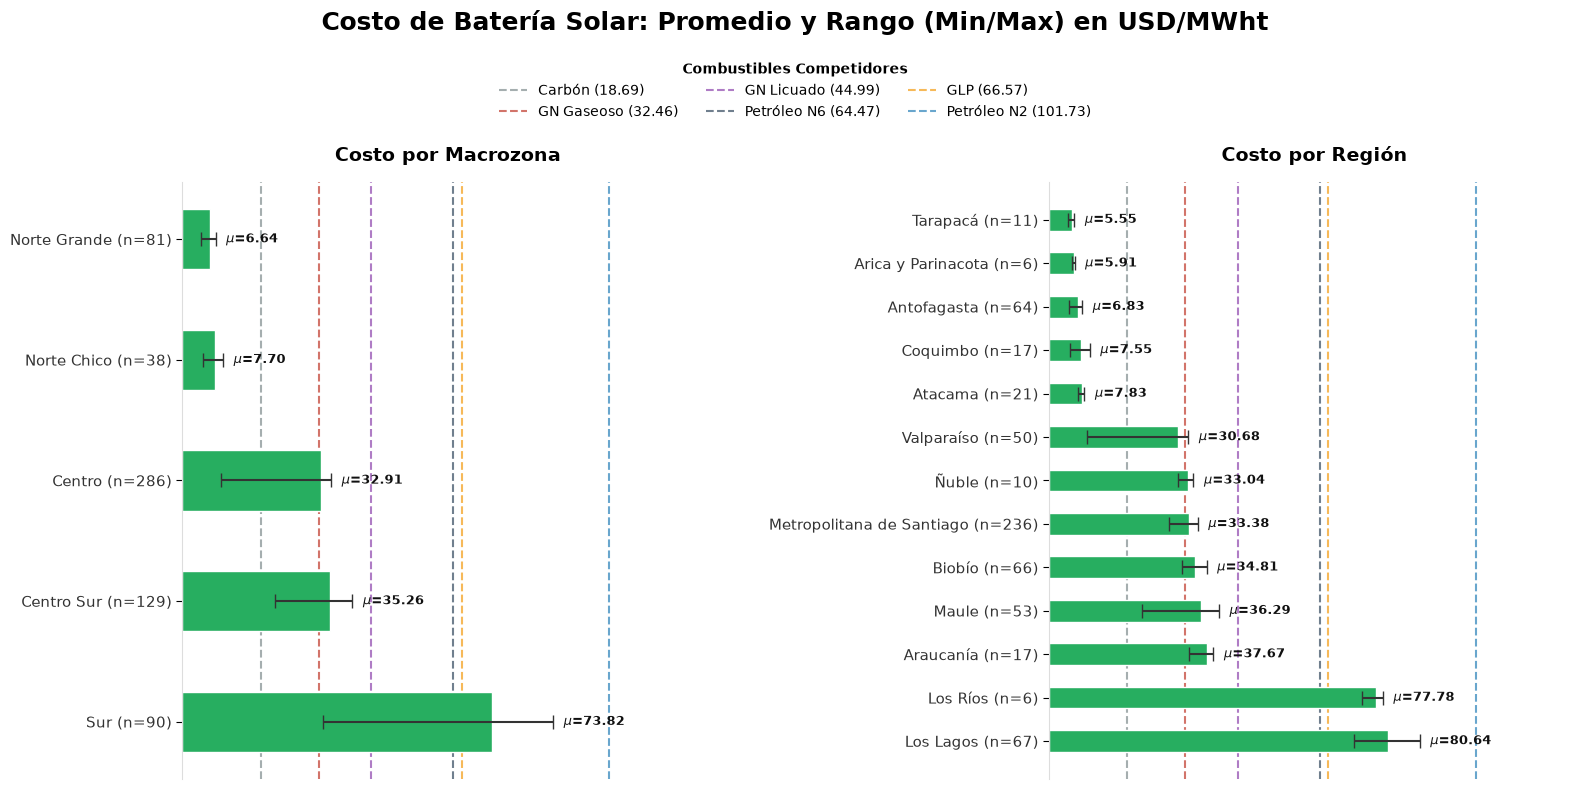

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def graficar_costos_con_bigotes(df, precio_dolar=926.41):
    
    # ==========================================
    # 1. PREPARACIÓN DE DATOS BASE
    # ==========================================
    # Nos quedamos con 1 registro por instalación (clave_unica) para no sesgar promedios
    df_base = df.drop_duplicates(subset=['clave_unica', 'macrozona', 'REGION_CLIENTE']).copy()
    
    # Convertimos el costo a USD/MWht directamente en la base
    df_base['costo_usd'] = df_base['costo_MWht_bateria'] / precio_dolar

    # ==========================================
    # 2. AGRUPACIÓN MACROZONA
    # ==========================================
    df_macro = df_base.groupby('macrozona', observed=False).agg(
        costo_mean=('costo_usd', 'mean'),
        costo_min=('costo_usd', 'min'),
        costo_max=('costo_usd', 'max'),
        total_instalaciones=('clave_unica', 'nunique')
    ).reset_index()
    
    orden_macrozonas = ["Norte Grande", "Norte Chico", "Centro", "Centro Sur", "Sur"]
    df_macro['macrozona'] = pd.Categorical(df_macro['macrozona'], categories=orden_macrozonas, ordered=True)
    df_macro = df_macro.sort_values('macrozona').reset_index(drop=True)
    
    # Cálculo de los errores (distancia desde la media)
    err_min_m = df_macro['costo_mean'] - df_macro['costo_min']
    err_max_m = df_macro['costo_max'] - df_macro['costo_mean']
    xerr_macro = [err_min_m, err_max_m]
    
    etiquetas_macro = df_macro['macrozona'].astype(str) + " (n=" + df_macro['total_instalaciones'].astype(str) + ")"

    # ==========================================
    # 3. AGRUPACIÓN REGIÓN
    # ==========================================
    df_region = df_base.groupby('REGION_CLIENTE').agg(
        costo_mean=('costo_usd', 'mean'),
        costo_min=('costo_usd', 'min'),
        costo_max=('costo_usd', 'max'),
        total_instalaciones=('clave_unica', 'nunique')
    ).reset_index()
    
    # Ordenamos por costo promedio (el más barato abajo para que al graficar quede arriba)
    df_region = df_region.sort_values('costo_mean', ascending=False).reset_index(drop=True)
    
    err_min_r = df_region['costo_mean'] - df_region['costo_min']
    print(err_min_r)
    err_max_r = df_region['costo_max'] - df_region['costo_mean']
    xerr_region = [err_min_r, err_max_r]
    
    etiquetas_region = df_region['REGION_CLIENTE'].astype(str) + " (n=" + df_region['total_instalaciones'].astype(str) + ")"

    # ==========================================
    # 4. CONFIGURACIÓN DEL LIENZO
    # ==========================================
    fig, axes = plt.subplots(1, 2, figsize=(16, max(8, len(df_region) * 0.5)))
    
    color_barra = '#27AE60' # Verde para la batería
    alto_barra = 0.5
    
    # Referencias de combustibles
    referencias = {
        'Carbón (18.69)': (18.69, '#7F8C8D'),          
        'GN Gaseoso (32.46)': (32.46, '#C0392B'),      
        'GN Licuado (44.99)': (44.99, '#8E44AD'),      
        'Petróleo N6 (64.47)': (64.47, '#34495E'),    
        'GLP (66.57)': (66.57, '#F39C12'),             
        'Petróleo N2 (101.73)': (101.73, '#2980B9')    
    }
    
    # Buscar el valor más alto general para fijar el límite del eje X (incluyendo bigotes y referencias)
    limite_max_datos = max(df_macro['costo_max'].max(), df_region['costo_max'].max())
    limite_x = max(limite_max_datos, 110) * 1.15 # 15% margen

    def dibujar_referencias(ax):
        for nombre, (valor, color) in referencias.items():
            ax.axvline(x=valor, color=color, linestyle='--', alpha=0.7, zorder=0, label=nombre)

    # ==========================================
    # 5. GRÁFICO 1: MACROZONA
    # ==========================================
    ax1 = axes[0]
    y_pos_macro = np.arange(len(df_macro))
    
    # Dibujamos las barras con 'xerr' para los bigotes (capsize dibuja los topes verticales)
    barras_m = ax1.barh(y_pos_macro, df_macro['costo_mean'], height=alto_barra, color=color_barra, 
                        edgecolor='white', xerr=xerr_macro, capsize=5, ecolor='#333333', error_kw={'linewidth': 1.5})
    
    ax1.set_yticks(y_pos_macro)
    ax1.set_yticklabels(etiquetas_macro, color='#333333', fontsize=11)
    ax1.invert_yaxis()
    ax1.set_xlim(0, limite_x)
    
    dibujar_referencias(ax1)
    
    # Etiquetas de texto (Promedio)
    for i, barra in enumerate(barras_m):
        ancho = barra.get_width()
        if ancho > 0:
            texto = f"$\mu$={ancho:.2f}"
            ax1.text(df_macro['costo_max'].iloc[i] + (limite_x * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=9.5, color='#111111', fontweight='600')

    ax1.set_title("Costo por Macrozona", fontsize=14, fontweight='bold', pad=15)
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)
    ax1.spines['bottom'].set_visible(False)
    ax1.spines['left'].set_color('#dddddd')
    ax1.get_xaxis().set_visible(False)
    ax1.tick_params(axis='y', length=4)

    # ==========================================
    # 6. GRÁFICO 2: REGIÓN
    # ==========================================
    ax2 = axes[1]
    y_pos_region = np.arange(len(df_region))
    
    barras_r = ax2.barh(y_pos_region, df_region['costo_mean'], height=alto_barra, color=color_barra, 
                        edgecolor='white', xerr=xerr_region, capsize=5, ecolor='#333333', error_kw={'linewidth': 1.5})
    
    ax2.set_yticks(y_pos_region)
    ax2.set_yticklabels(etiquetas_region, color='#333333', fontsize=11)
    # Ya está ordenado, no invertimos para que las más baratas queden arriba
    ax2.set_xlim(0, limite_x)
    
    dibujar_referencias(ax2)

    for i, barra in enumerate(barras_r):
        ancho = barra.get_width()
        if ancho > 0:
            texto = f"$\mu$={ancho:.2f}"
            ax2.text(df_region['costo_max'].iloc[i] + (limite_x * 0.02), barra.get_y() + barra.get_height()/2, 
                     texto, va='center', ha='left', fontsize=9.5, color='#111111', fontweight='600')

    ax2.set_title("Costo por Región", fontsize=14, fontweight='bold', pad=15)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.spines['left'].set_color('#dddddd')
    ax2.get_xaxis().set_visible(False)
    ax2.tick_params(axis='y', length=4)

    # ==========================================
    # 7. SUPER TÍTULO Y LEYENDA GLOBAL
    # ==========================================
    fig.suptitle("Costo de Batería Solar: Promedio y Rango (Min/Max) en USD/MWht", 
                 fontsize=18, fontweight='bold', y=0.98)

    # Solo necesitamos usar los handles de uno de los gráficos (ej. ax2) para la leyenda
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.93), 
               ncol=3, frameon=False, title='Combustibles Competidores', title_fontproperties={'weight': 'bold'})

    plt.tight_layout(rect=[0, 0, 1, 0.88], w_pad=4)
    plt.show()

# Ejecución:
graficar_costos_con_bigotes(df_dt)